# Fashion dataset exploratory analysis

This notebook describes the **38,612 image-matched official training products** reviewed in Phase 0. Each product has one original image and one teacher low-resolution image, usually 60×80. These are paired views, not separate products.

Phase 0 found one unusable blank product image, ID **44998**. Phase 1 will record and exclude it.

The notebook provides evidence for later decisions. It does not edit raw labels or create a data split.

In [1]:
from __future__ import annotations

import os
from pathlib import Path

import pandas as pd
from IPython.display import Image as DisplayImage, Markdown, display

from fashion.config import EDA_OUTPUT_DIR, TARGET_COLUMNS
from fashion.eda import load_eda_summary, run_eda

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 150)
OUTPUT = Path(EDA_OUTPUT_DIR)

/localhome/local-lintran/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-5qswcez_ because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## 1. Build or load the evidence

The implementation lives in `src/fashion/`. A normal notebook run reuses image measurements only when their source files and settings still match. Set `MLA2_RECOMPUTE_EDA=1` to force a full rescan.

Only official training IDs are analysed. Test labels are never loaded.

In [2]:
refresh = os.getenv("MLA2_RECOMPUTE_EDA", "0") == "1"
result = run_eda(output_dir=OUTPUT, refresh=refresh)
summary = load_eda_summary(OUTPUT)

population = summary["population"]
quarantine = summary["test_quarantine"]
display(Markdown(f"""
- **{population['source_train_ids']:,}** official training IDs
- **{population['usable_products']:,}** usable paired products
- **{quarantine['test_id_count']:,}** quarantined test IDs
- **{quarantine['overlap_count']:,}** train/test overlap
"""))
print("Image cache:", dict(result.cache_status))


- **38,617** official training IDs
- **38,612** usable paired products
- **5,829** quarantined test IDs
- **0** train/test overlap


Image cache: {'lowres': 'reused', 'highres': 'reused', 'near_lowres': 'reused'}


## 2. Raw-data and reconciliation audit

The CSV audit keeps comma-spilled product names visible, preserves literal `"NA"`, and reports every metadata/image mismatch. These findings are evidence only; nothing is cleaned here.

In [3]:
import json

data_audit = json.loads((OUTPUT / "data-audit.json").read_text(encoding="utf-8"))
name_audit = json.loads((OUTPUT / "product-name-audit.json").read_text(encoding="utf-8"))
hierarchy = pd.read_csv(OUTPUT / "hierarchy-conflicts.csv", keep_default_na=False)

teacher_audit = data_audit["teacher_csv_audit"]
display(Markdown(f"""
### Raw-data facts

Original metadata is read for IDs only, so it has no label audit here.

- Teacher CSV: **{teacher_audit['row_count']:,}** rows; **{sum(teacher_audit['phantom_nonempty_counts'].values()):,}** nonempty spill cells.
- Literal usage `"NA"`: **{teacher_audit['literal_na_usage_count']:,}** teacher rows.
- Missing both image views: **{len(data_audit['missing_both_image_ids']):,}** IDs — {data_audit['missing_both_image_ids']}.
- Unmatched original images: **{len(data_audit['unmatched_original_image_ids']):,}**; unmatched low-resolution images: **{len(data_audit['unmatched_lowres_image_ids']):,}**.
- Invalid image filenames: **{len(data_audit['invalid_original_image_filenames']) + len(data_audit['invalid_lowres_image_filenames']):,}**.
- Hierarchy-conflict labels: **{len(hierarchy):,}**.
- Product-name/gender review candidates: **{len(name_audit['gender_contradiction_candidates']):,}**.
- Missing product names: **{name_audit['missing_name_count']:,}**.
"""))


### Raw-data facts

Original metadata is read for IDs only, so it has no label audit here.

- Teacher CSV: **38,617** rows; **23** nonempty spill cells.
- Literal usage `"NA"`: **71** teacher rows.
- Missing both image views: **5** IDs — [12347, 39401, 39403, 39410, 39425].
- Unmatched original images: **5,829**; unmatched low-resolution images: **0**.
- Invalid image filenames: **0**.
- Hierarchy-conflict labels: **20**.
- Product-name/gender review candidates: **396**.
- Missing product names: **0**.


## 3. Metadata quality and complete distributions

Every available metadata field is included: ID, gender, category hierarchy, article type, colour, season, year, usage, and product name.

The literal usage label `"NA"` is a real class. It is kept separate from a genuinely blank value.

In [4]:
metadata_distributions = pd.read_csv(OUTPUT / "metadata-distributions.csv", keep_default_na=False)
target_skew = pd.read_csv(OUTPUT / "target-skew.csv", keep_default_na=False)
support = pd.read_csv(OUTPUT / "article-type-support.csv", keep_default_na=False)

usage_skew_preview = target_skew.set_index("column").loc["usage"]
display(Markdown(f"""
The charts below show the full target distributions and long tail directly. The strongest skew is `usage`: its largest class contains **{usage_skew_preview['majority_share']:.1%}** of nonblank products.
"""))


The charts below show the full target distributions and long tail directly. The strongest skew is `usage`: its largest class contains **76.8%** of nonblank products.


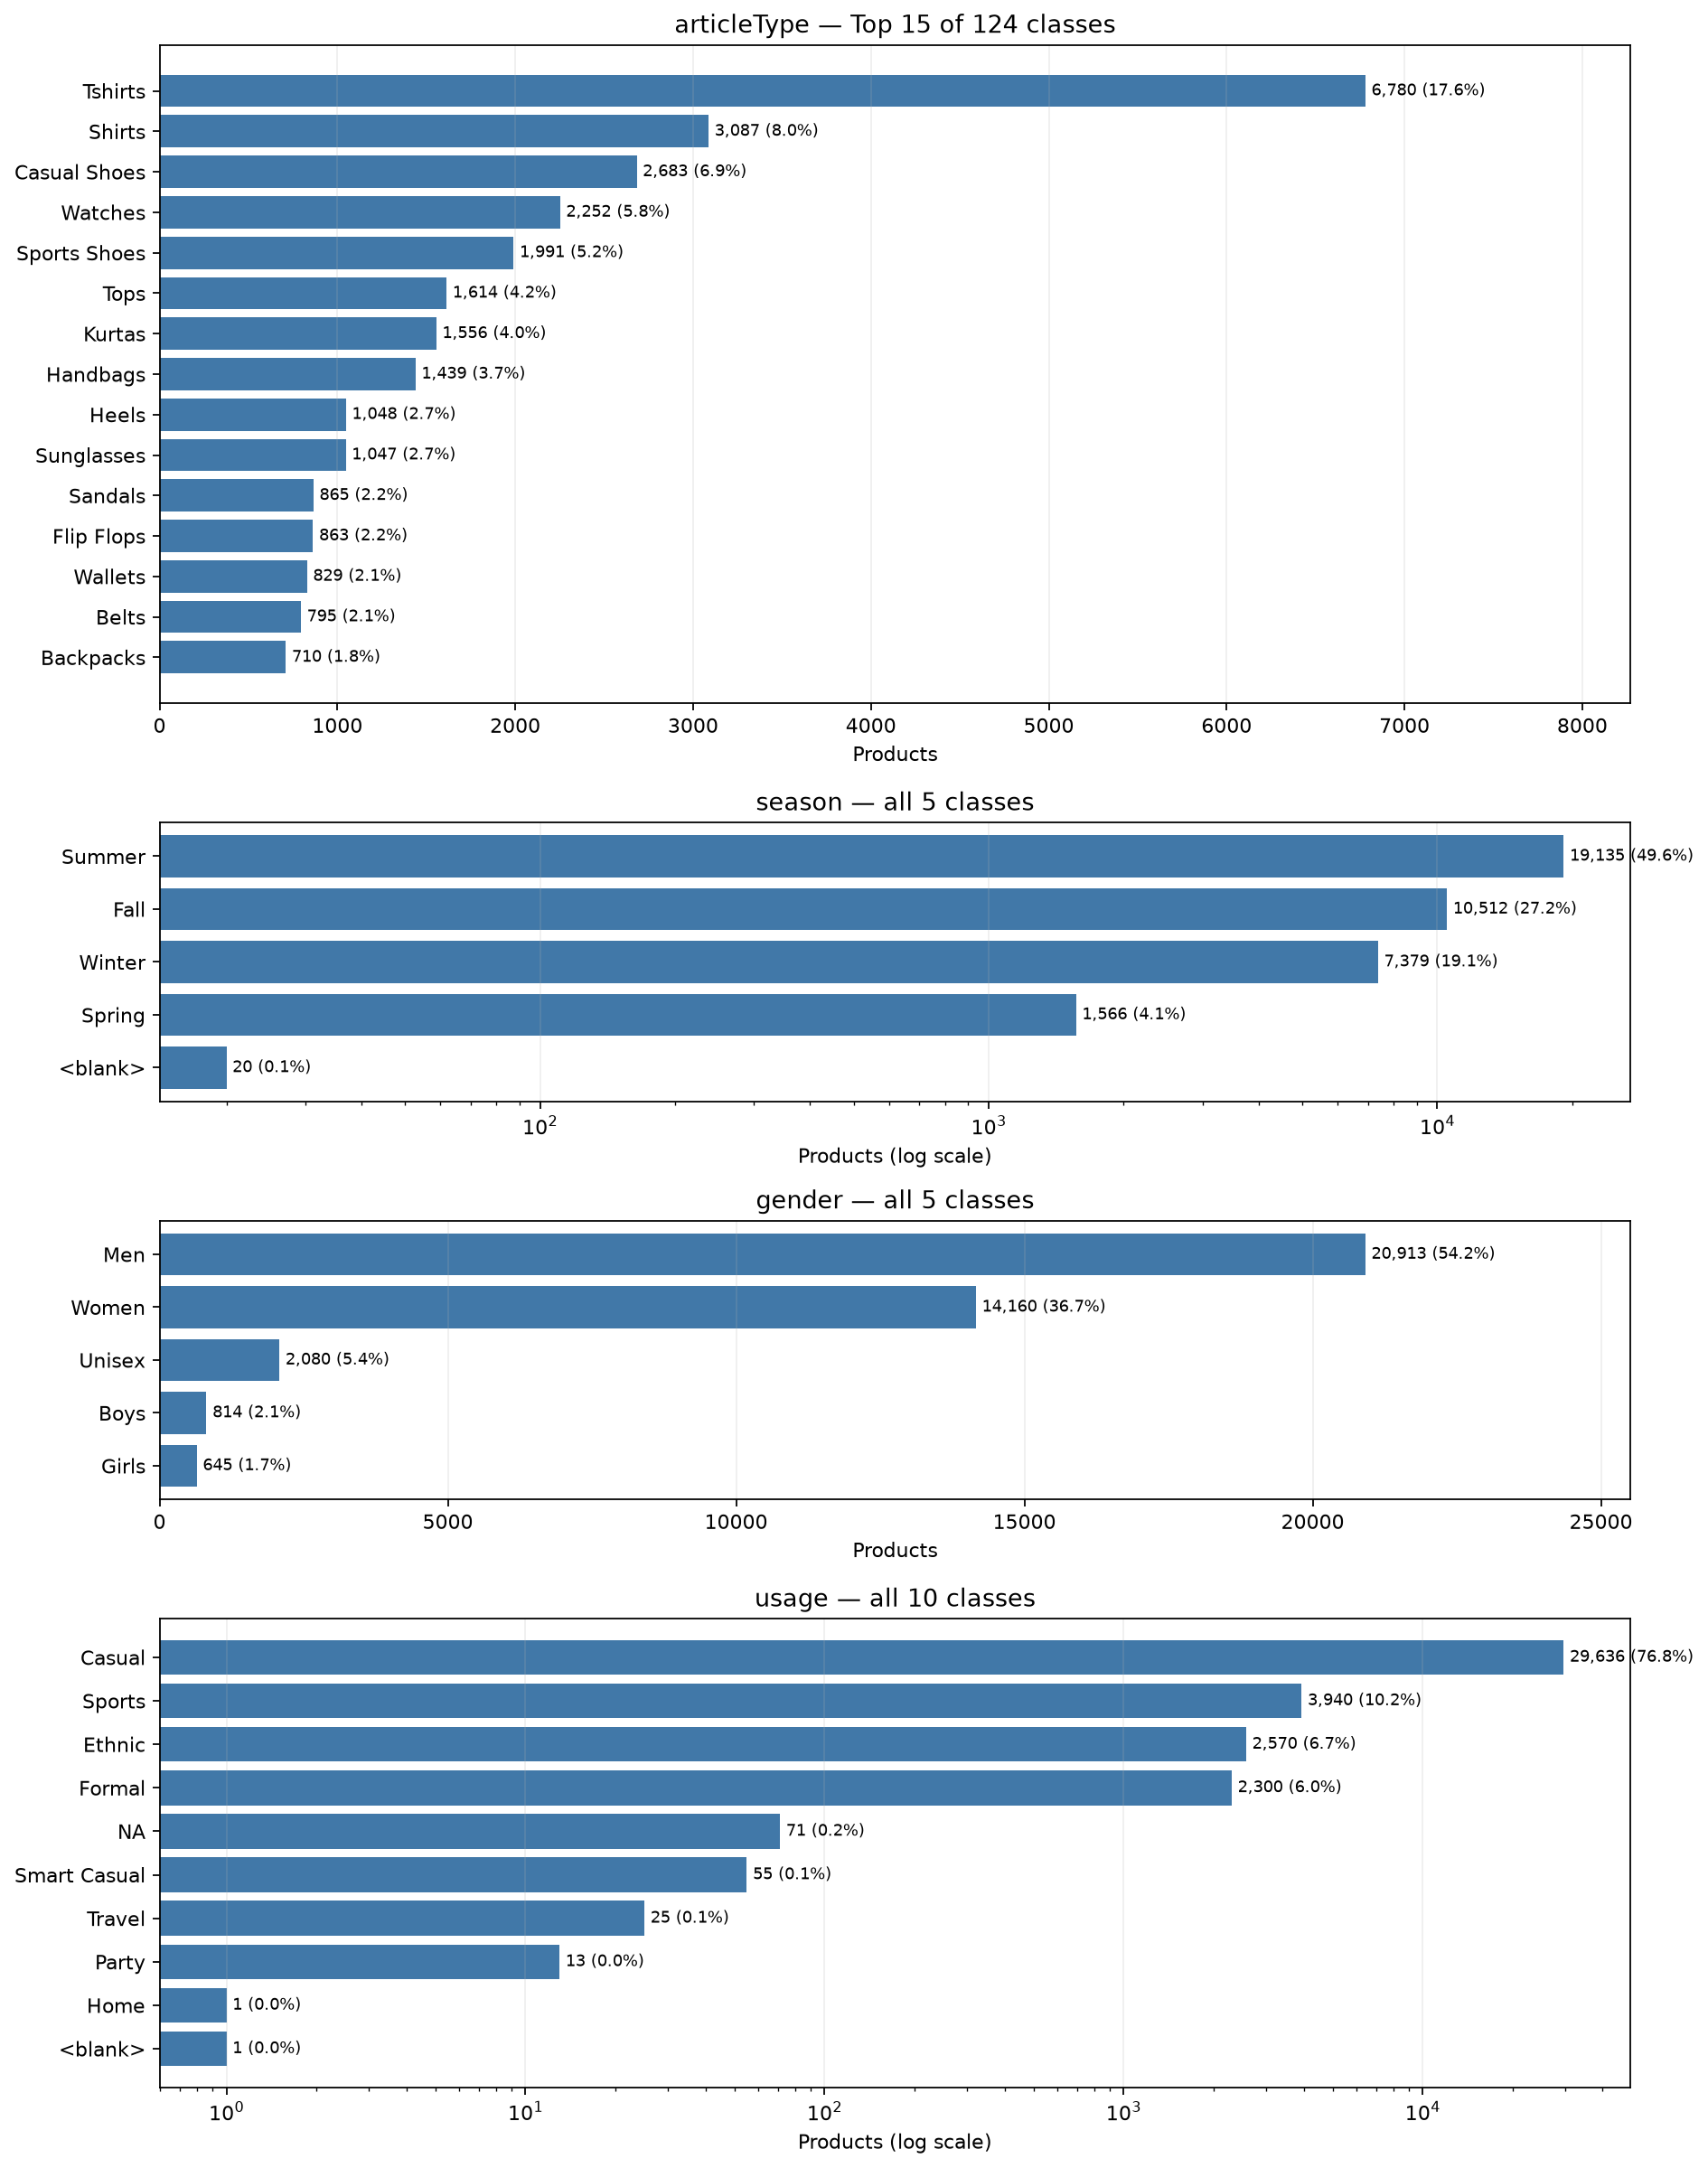

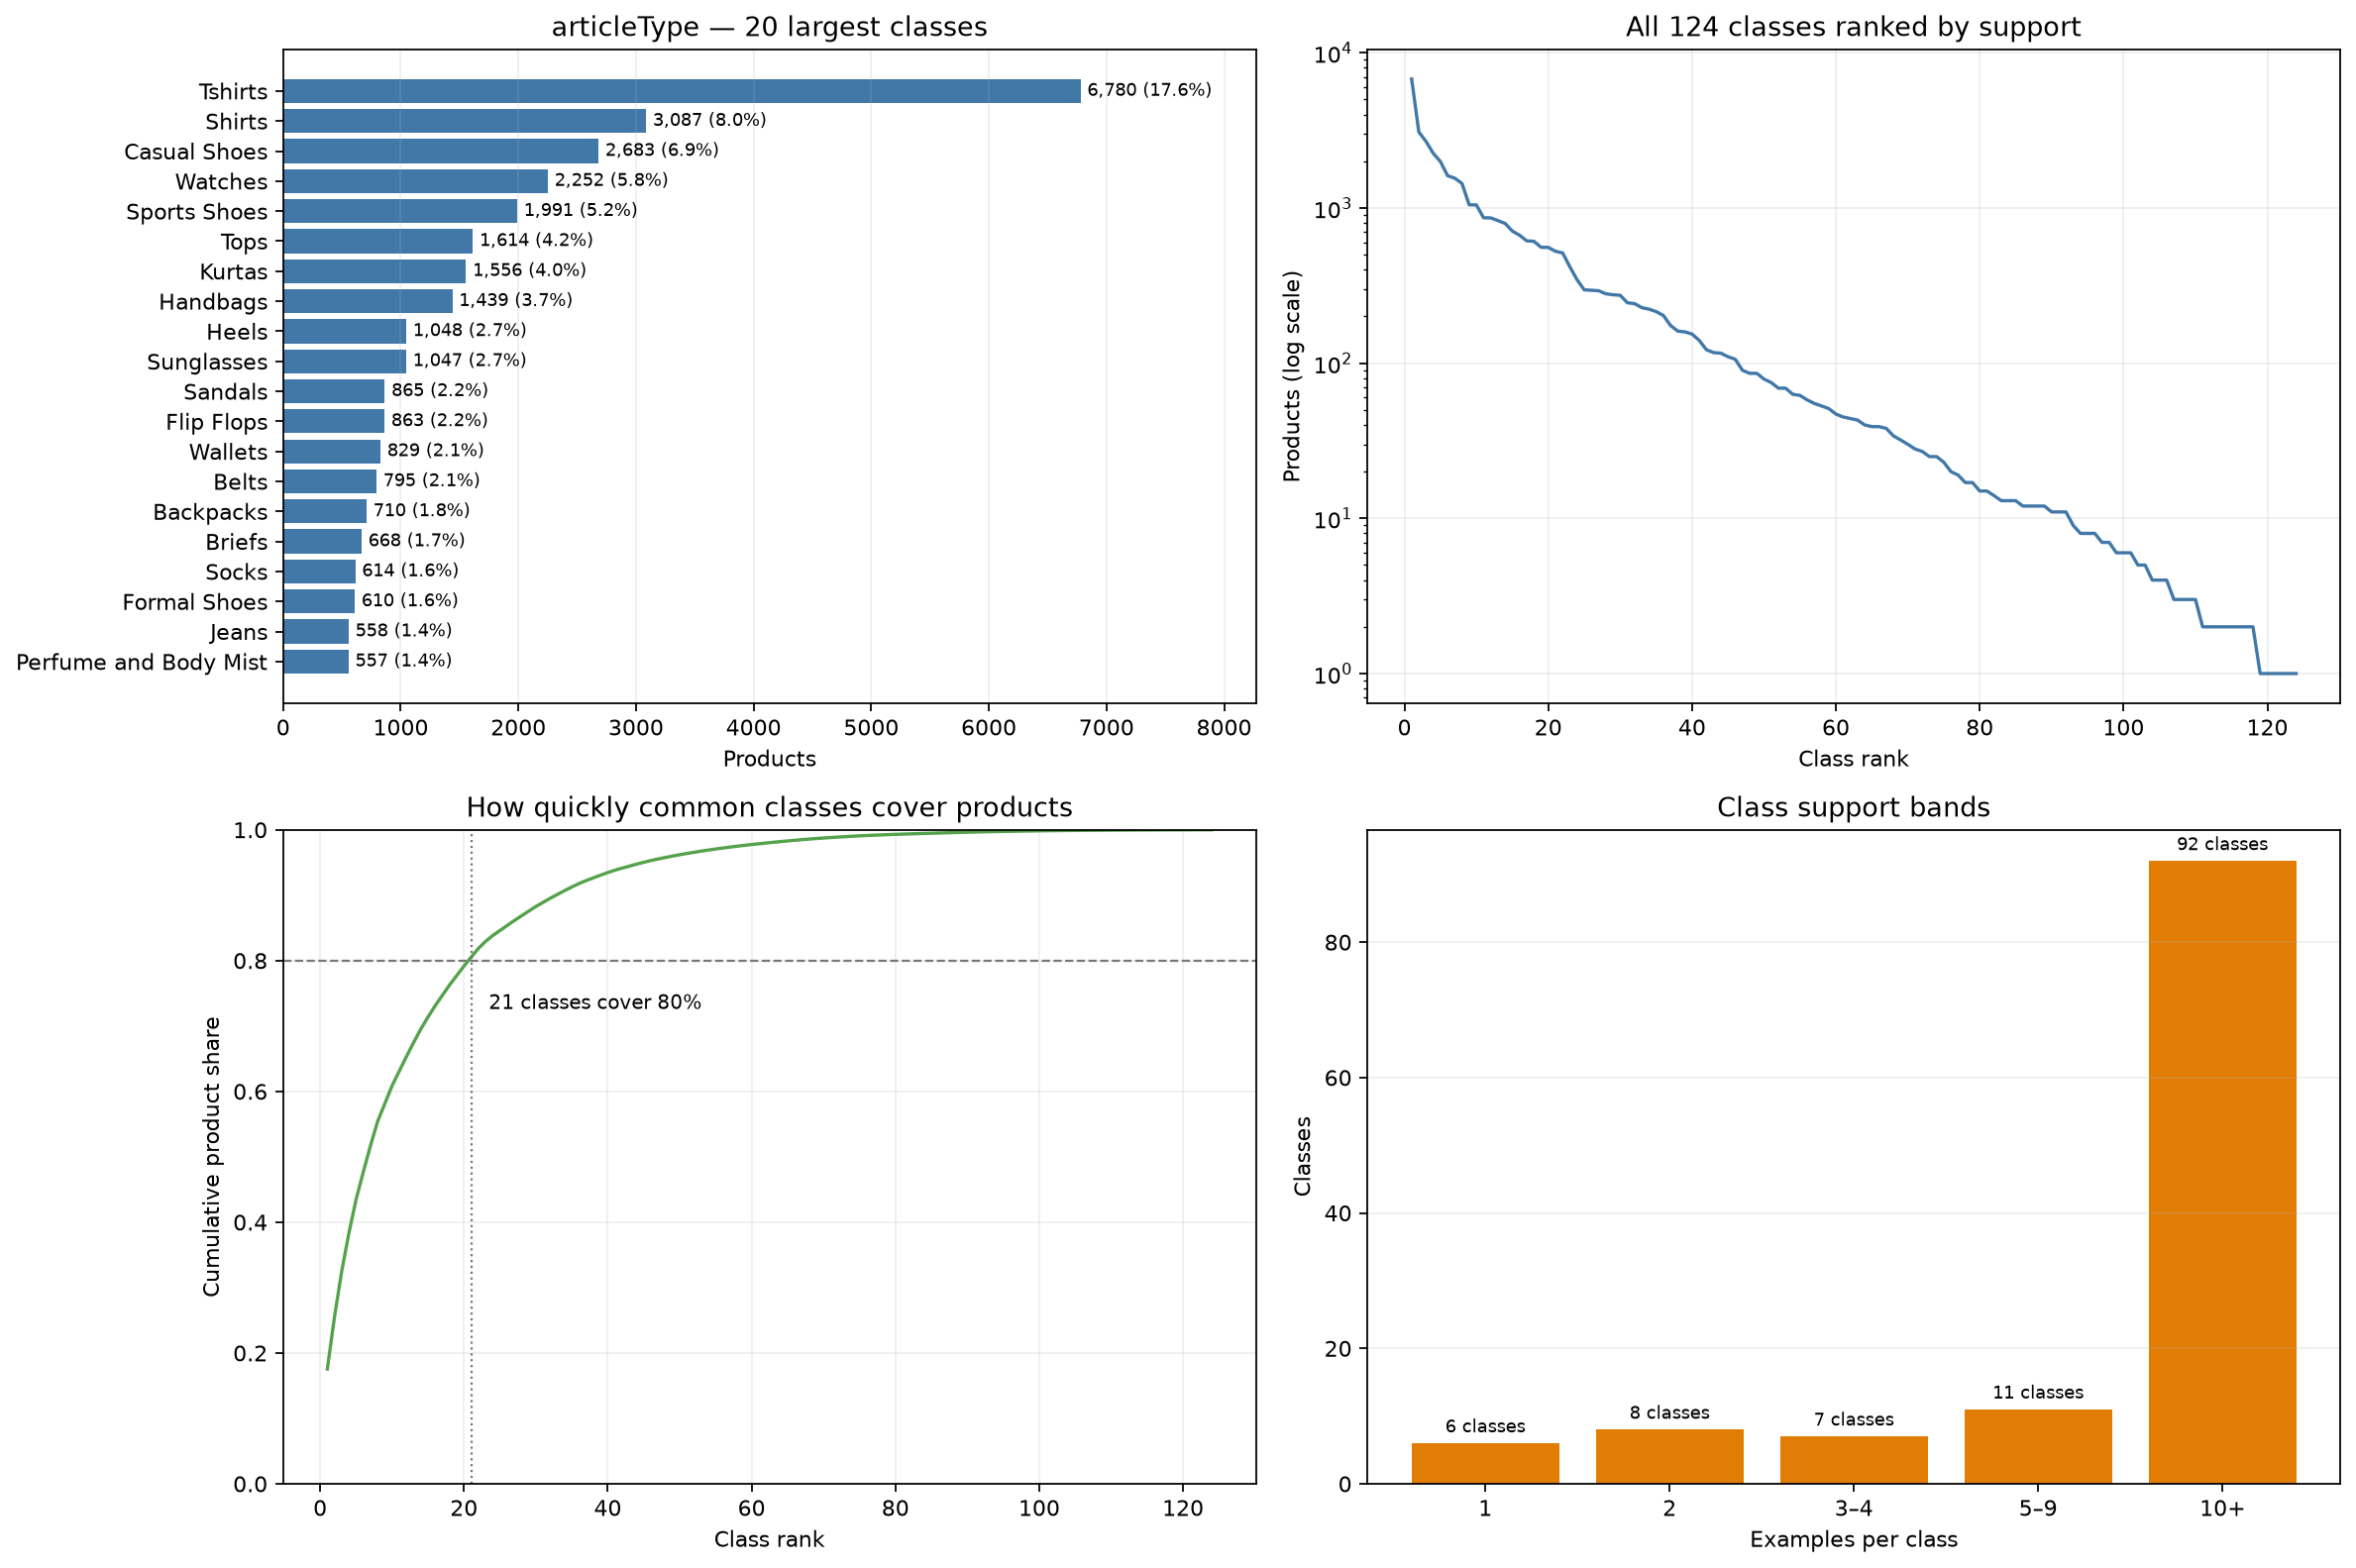

In [5]:
display(DisplayImage(filename=str(OUTPUT / "target-distributions.png")))
display(DisplayImage(filename=str(OUTPUT / "article-type-support.png")))

## 4. Dataset scope: every `masterCategory`

This chart lists every master category in the selected training population. Small categories such as `Personal Care`, `Free Items`, `Sporting Goods`, and `Home` show that the dataset is broader than clothing alone. Their relevance to the fashion tasks needs a separate decision later.

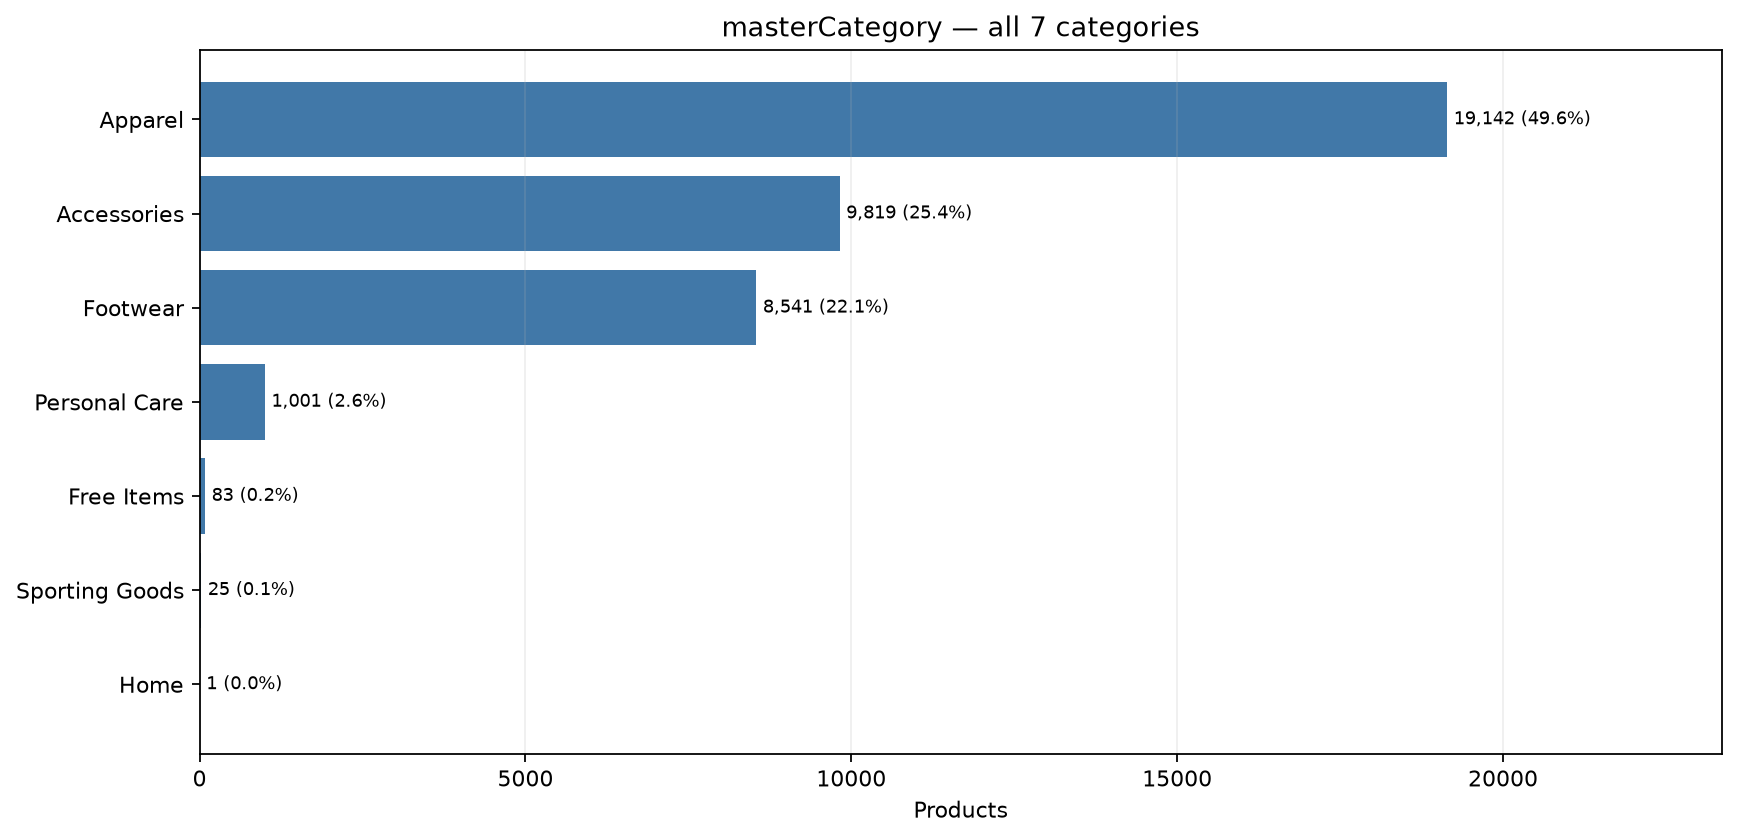

In [6]:
display(DisplayImage(filename=str(OUTPUT / "master-category-distribution.png")))

## 5. Relationships and dataset drift

Normal numeric correlation is not valid for word labels. The matrix uses **Cramér's V**, where 0 means little categorical relationship and 1 means a deterministic relationship.

The detailed heatmaps show which labels occur together. Drift tables compare each year or catalogue-ID range with the full training population. ID is catalogue order, not guaranteed time. Very small year groups can produce large, unstable drift values, so their row counts must be read with the score.

In [7]:
associations = pd.read_csv(OUTPUT / "associations.csv", index_col=0)
gender_usage = pd.read_csv(OUTPUT / "gender-usage.csv", index_col=0)
year_drift = pd.read_csv(OUTPUT / "year-drift.csv", keep_default_na=False)
id_drift = pd.read_csv(OUTPUT / "id-range-drift.csv", keep_default_na=False)

strongest = summary["associations"]["strongest_pair"]
display(Markdown(f"Strongest readable measured pair: `{strongest['left']}` × `{strongest['right']}`. The diagrams below show association strength, label mixtures, and drift directly."))

Strongest readable measured pair: `masterCategory` × `season`. The diagrams below show association strength, label mixtures, and drift directly.

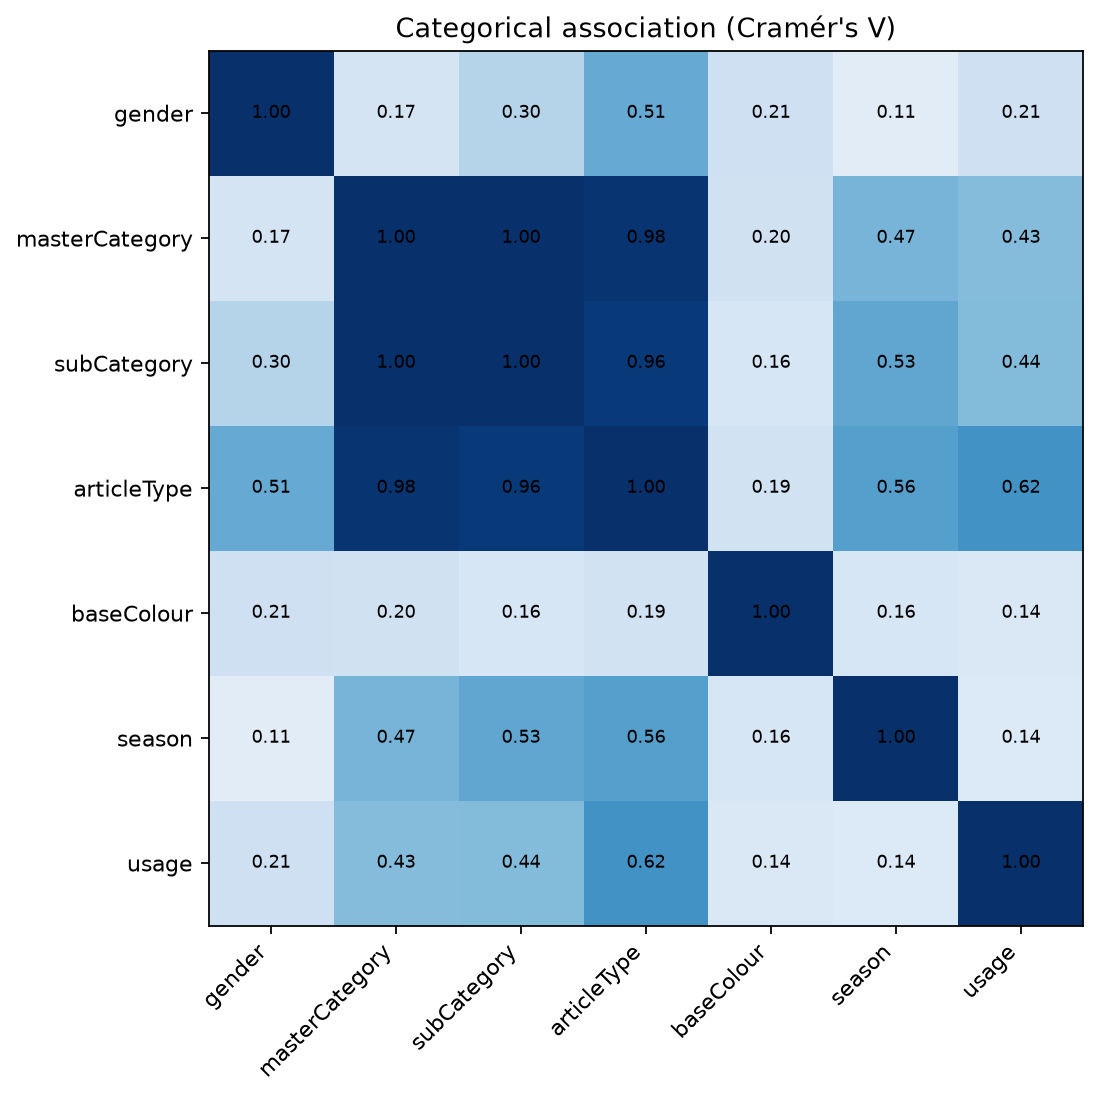

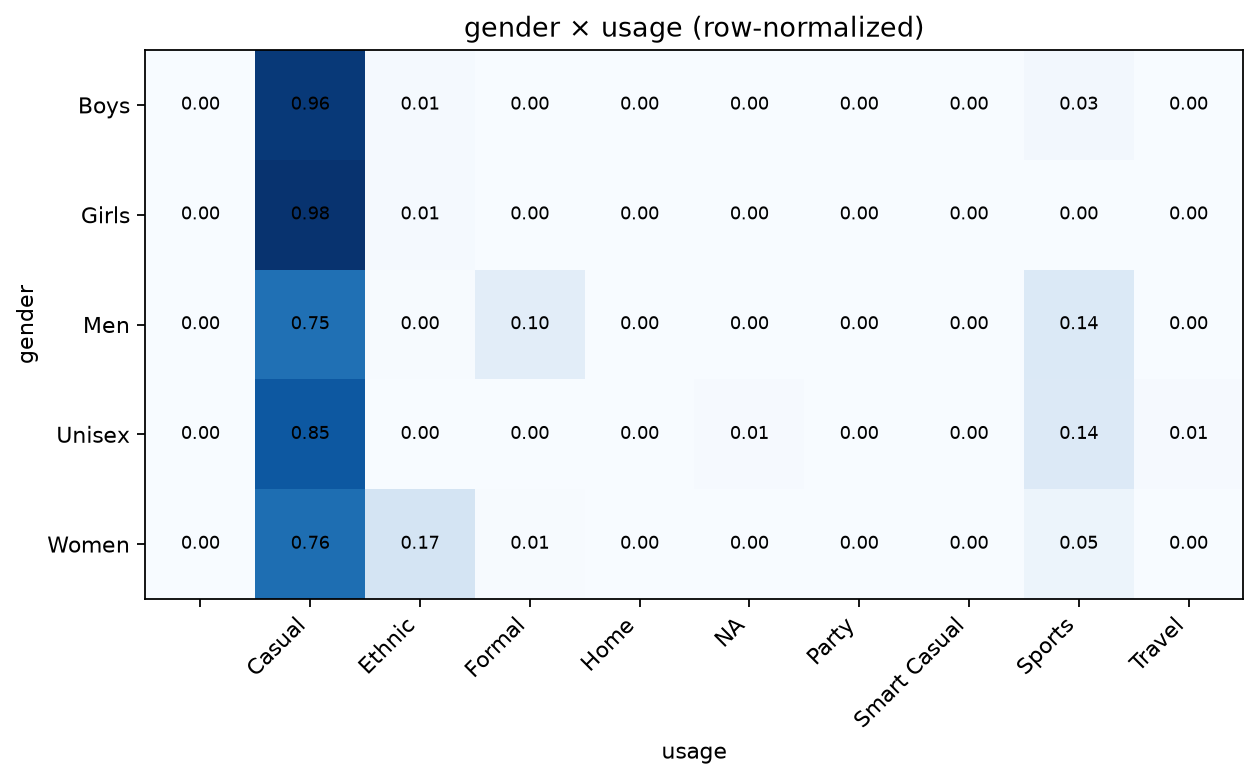

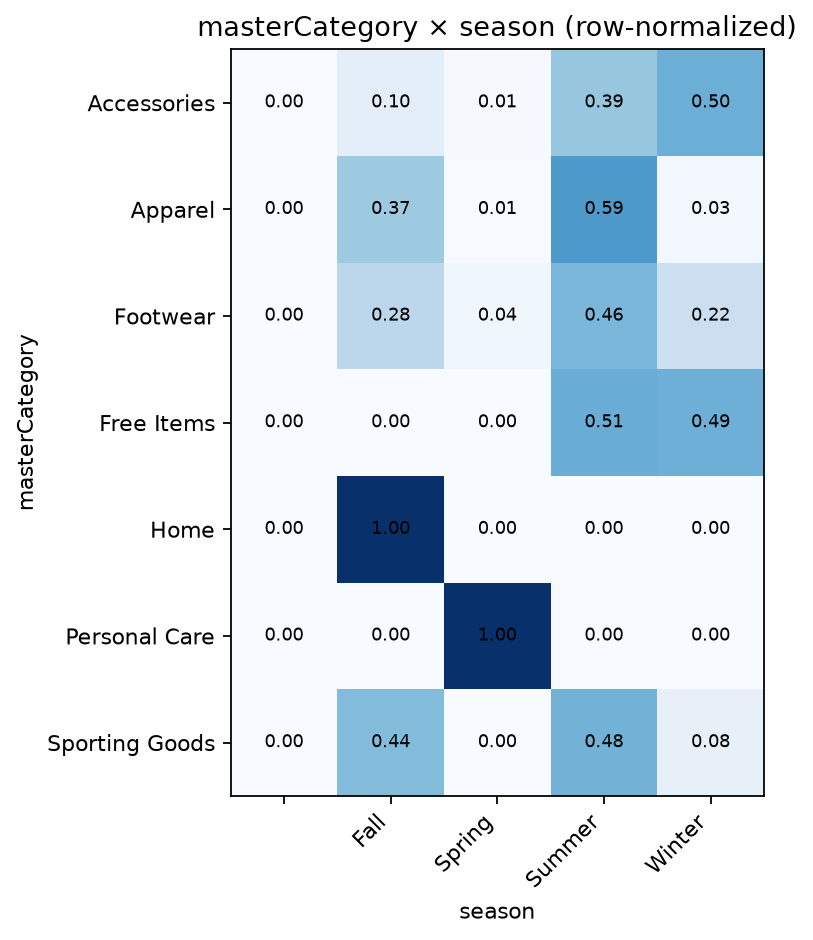

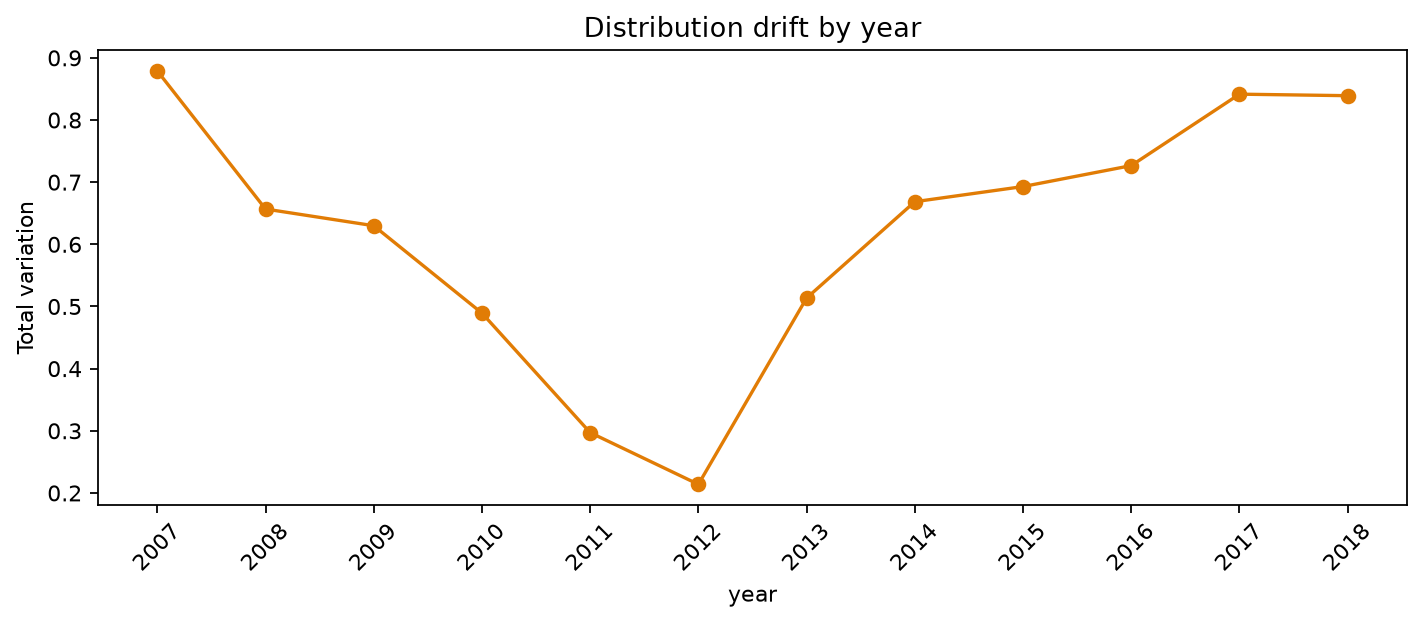

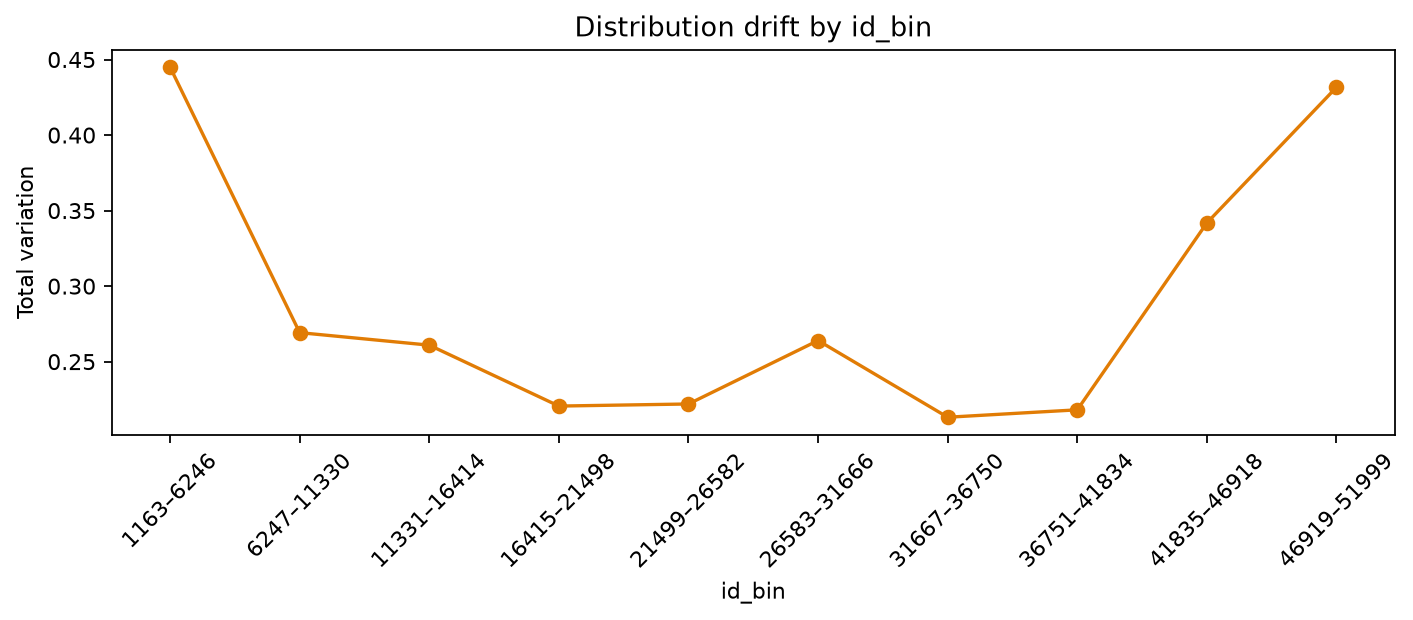

In [8]:
for filename in (
    "associations.png",
    "gender-usage.png",
    "strongest-relationship.png",
    "year-drift.png",
    "id-range-drift.png",
):
    display(DisplayImage(filename=str(OUTPUT / filename)))

## 6. Image properties and duplicate risk

Every supplied low-resolution training image is measured; unusual sizes remain visible rather than being called 60×80. Original images use a fixed, proportionally stratified sample of at most 2,048 products. Measurements include shape, colour mode, file size, brightness, contrast, colourfulness, saturation, and edge sharpness.

Byte-identical files form exact-duplicate groups. Difference-hash matches are only **review candidates**; they are not automatically merged.

In [9]:
lowres = pd.read_csv(OUTPUT / "lowres-measurements.csv", keep_default_na=False, dtype={"dhash": "string"})
highres = pd.read_csv(OUTPUT / "highres-measurements.csv", keep_default_na=False, dtype={"dhash": "string"})
paired = pd.read_csv(OUTPUT / "paired-image-comparison.csv", keep_default_na=False)
exact = pd.read_csv(OUTPUT / "exact-duplicates.csv", keep_default_na=False)
near = pd.read_csv(OUTPUT / "near-duplicates.csv", keep_default_na=False)

nonstandard = int(lowres.loc[~(lowres["width"].eq(60) & lowres["height"].eq(80))].shape[0])
duplicate_counts = summary["duplicates"]
brightness_review = summary["brightness_background_review"]
display(Markdown(f"""
- Low-resolution images measured: **{len(lowres):,}**; read errors: **{int(lowres['error'].ne('').sum()):,}**.
- Original images sampled: **{len(highres):,}**; read errors: **{int(highres['error'].ne('').sum()):,}**.
- Images outside 60×80: **{nonstandard:,}**.
- Exact groups: **{duplicate_counts['exact_group_count']:,}**, covering **{duplicate_counts['exact_product_count']:,}** products.
- Sampled near-candidate pairs: **{duplicate_counts['near_candidate_pair_count']:,}** from **{duplicate_counts['near_sample_product_count']:,}** products.
- **Drop ID {brightness_review['exclude_unusable_ids'][0]}:** both image views are blank white, so the product gives the model no visual evidence.
- **Keep IDs {brightness_review['keep_valid_bright_ids'][0]} and {brightness_review['keep_valid_dark_background_ids'][0]}:** they are valid products on very bright and dark backgrounds.

The diagrams below show image-property differences, duplicate counts, and visual examples directly.
"""))


- Low-resolution images measured: **38,612**; read errors: **0**.
- Original images sampled: **2,048**; read errors: **0**.
- Images outside 60×80: **17**.
- Exact groups: **636**, covering **1,399** products.
- Sampled near-candidate pairs: **4,383** from **2,048** products.
- **Drop ID 44998:** both image views are blank white, so the product gives the model no visual evidence.
- **Keep IDs 48716 and 43113:** they are valid products on very bright and dark backgrounds.

The diagrams below show image-property differences, duplicate counts, and visual examples directly.


### Blank image versus valid background extremes

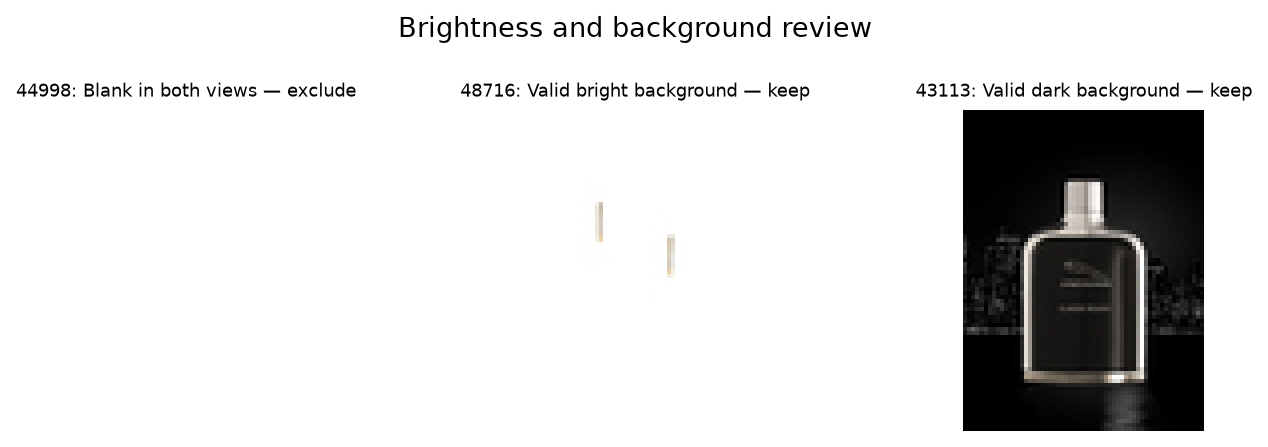

**Decision:** exclude only the blank ID `44998` through `label_review.csv`. Keep valid bright and dark-background images. Use training-only brightness, contrast, and colour changes so the model learns the product instead of the background.

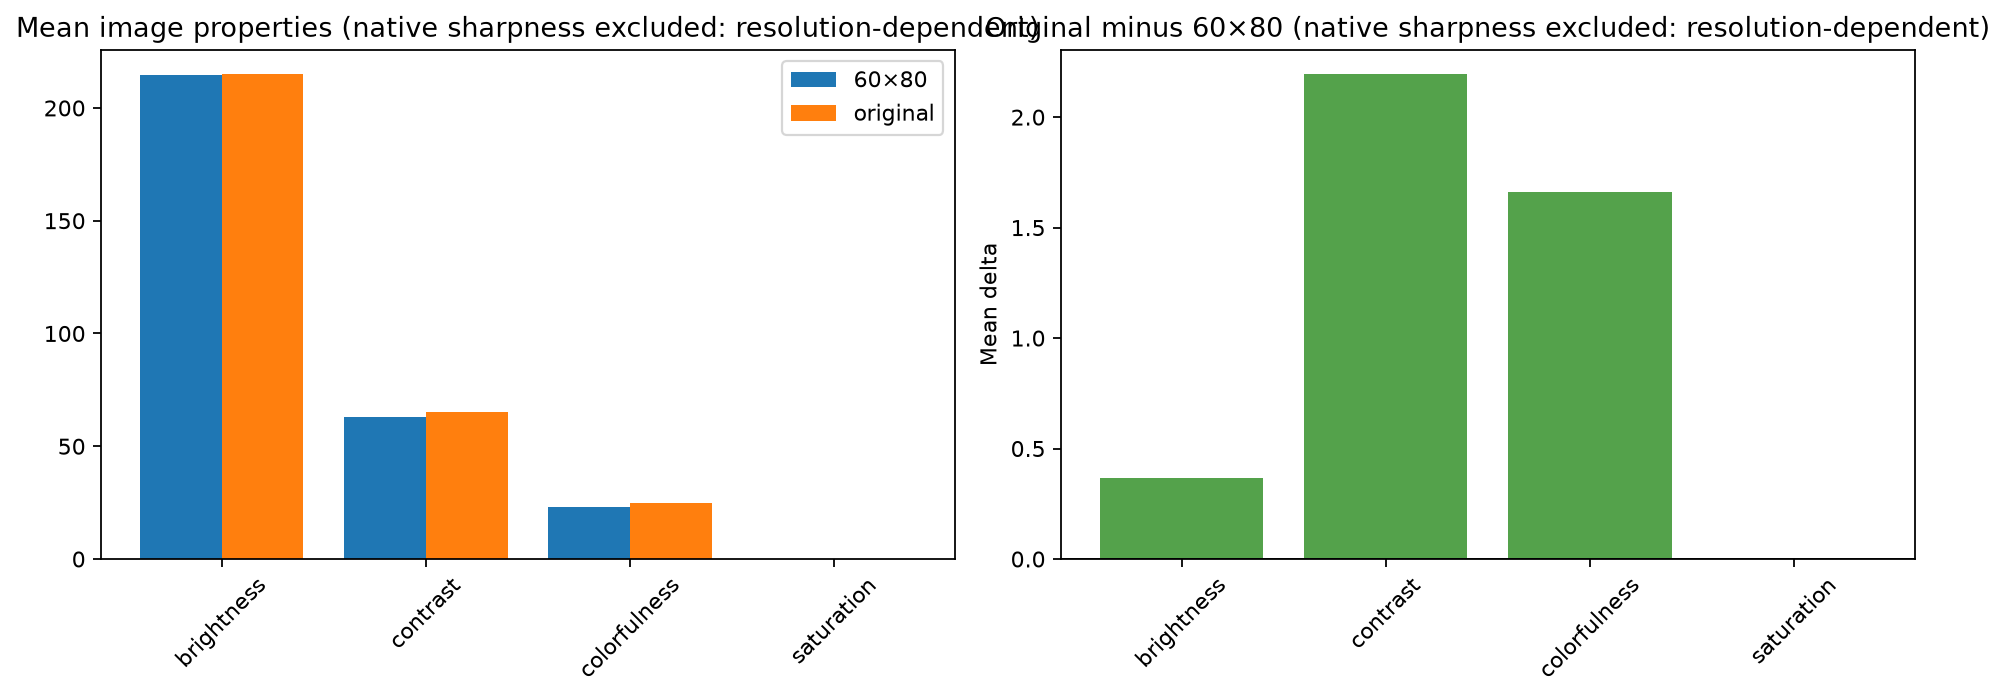

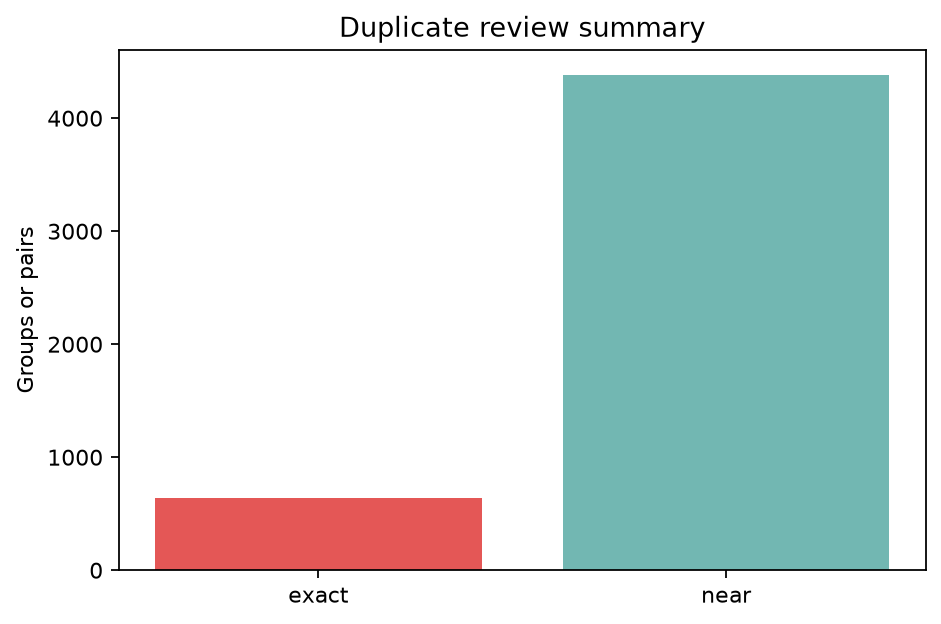

### Common classes

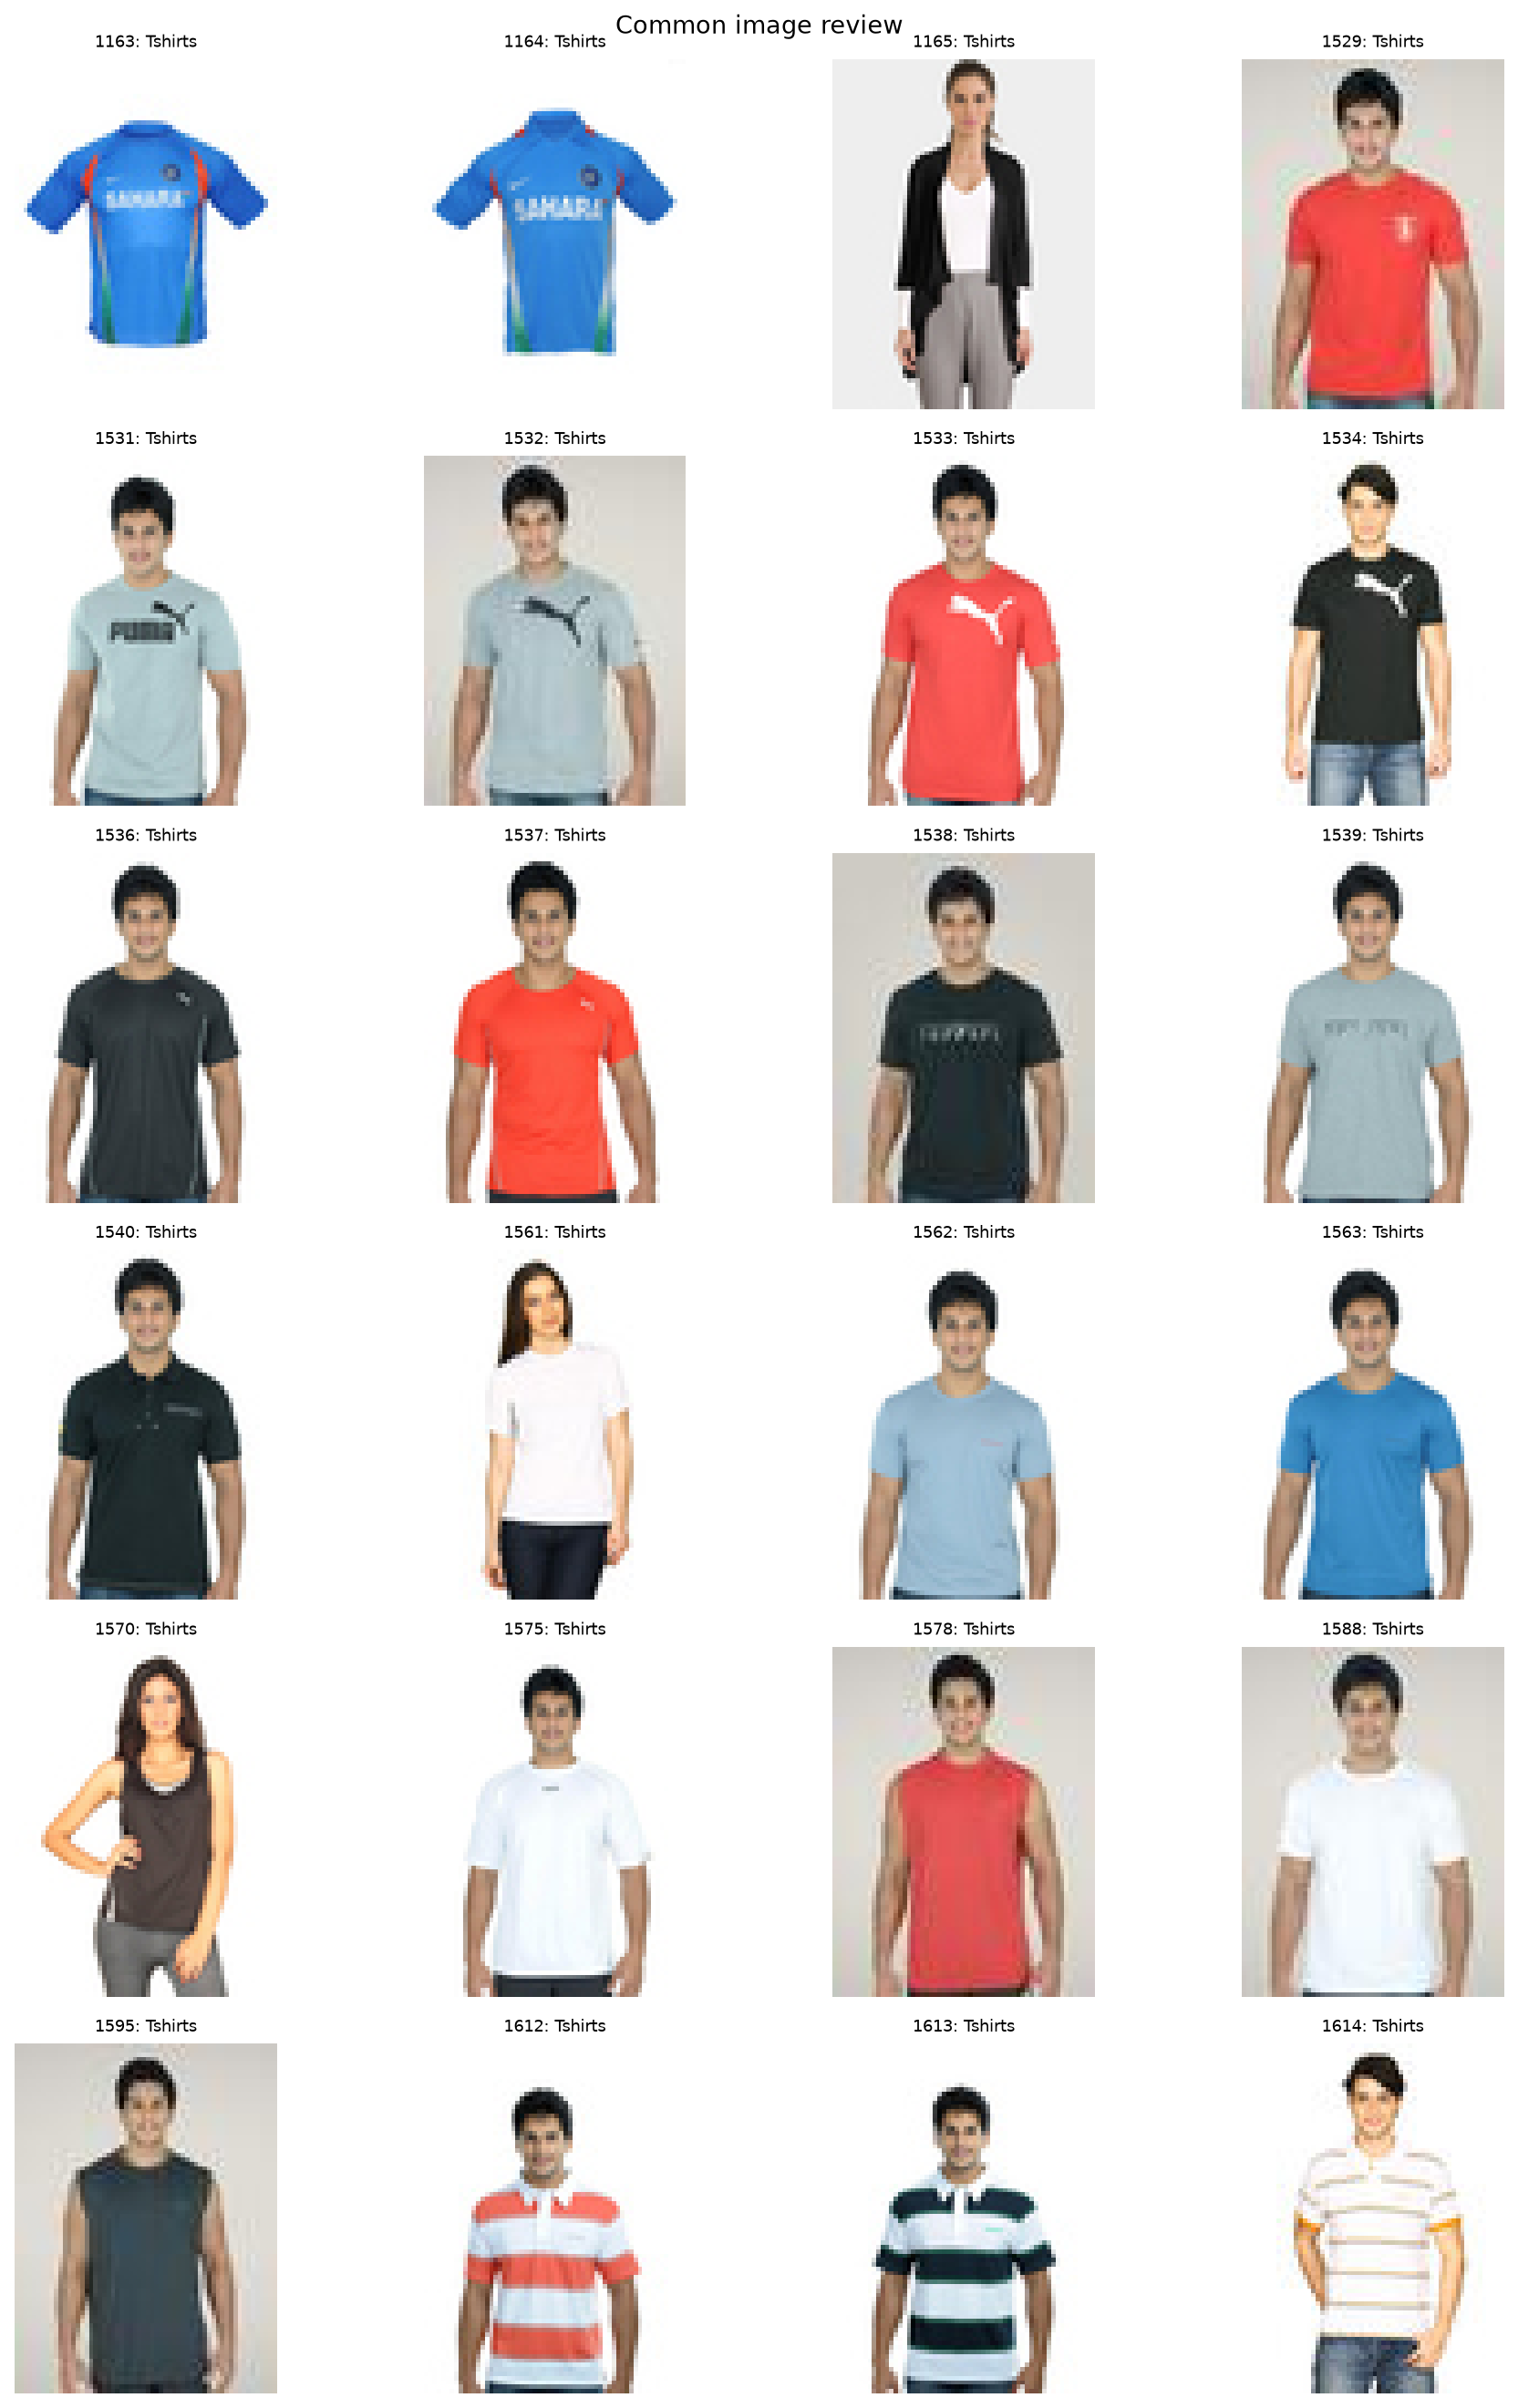

### Rare classes

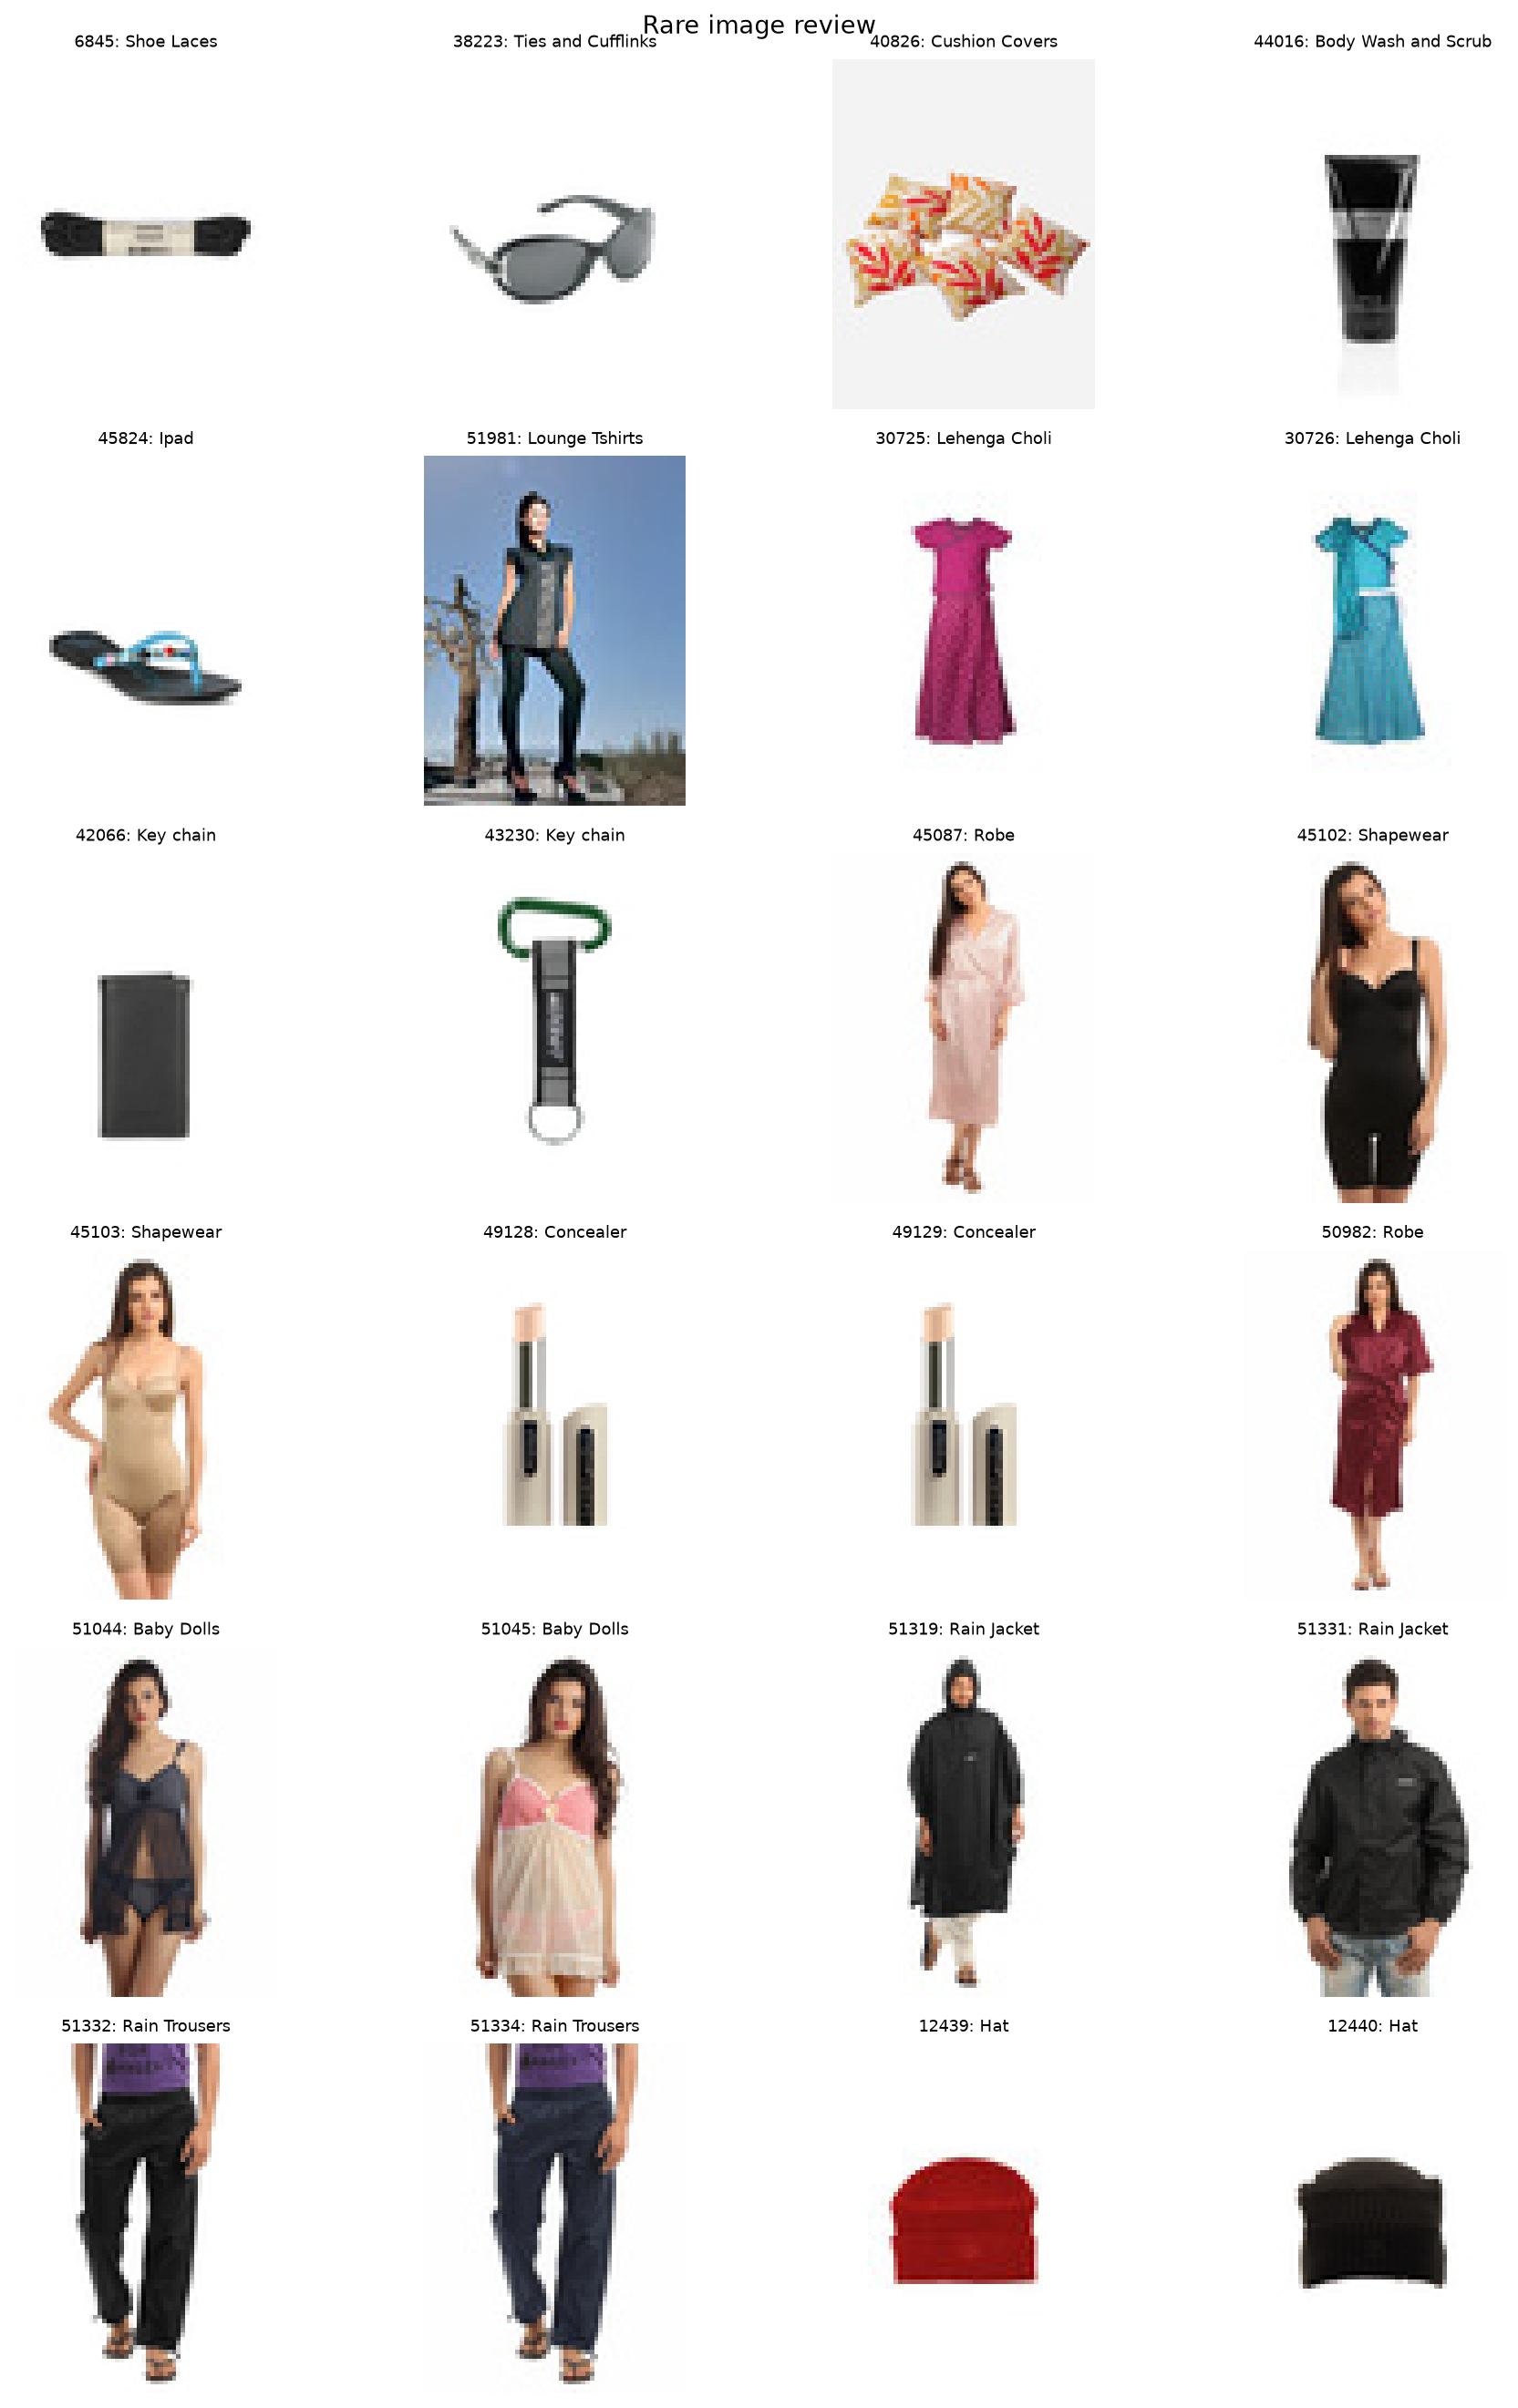

### Unusual image properties

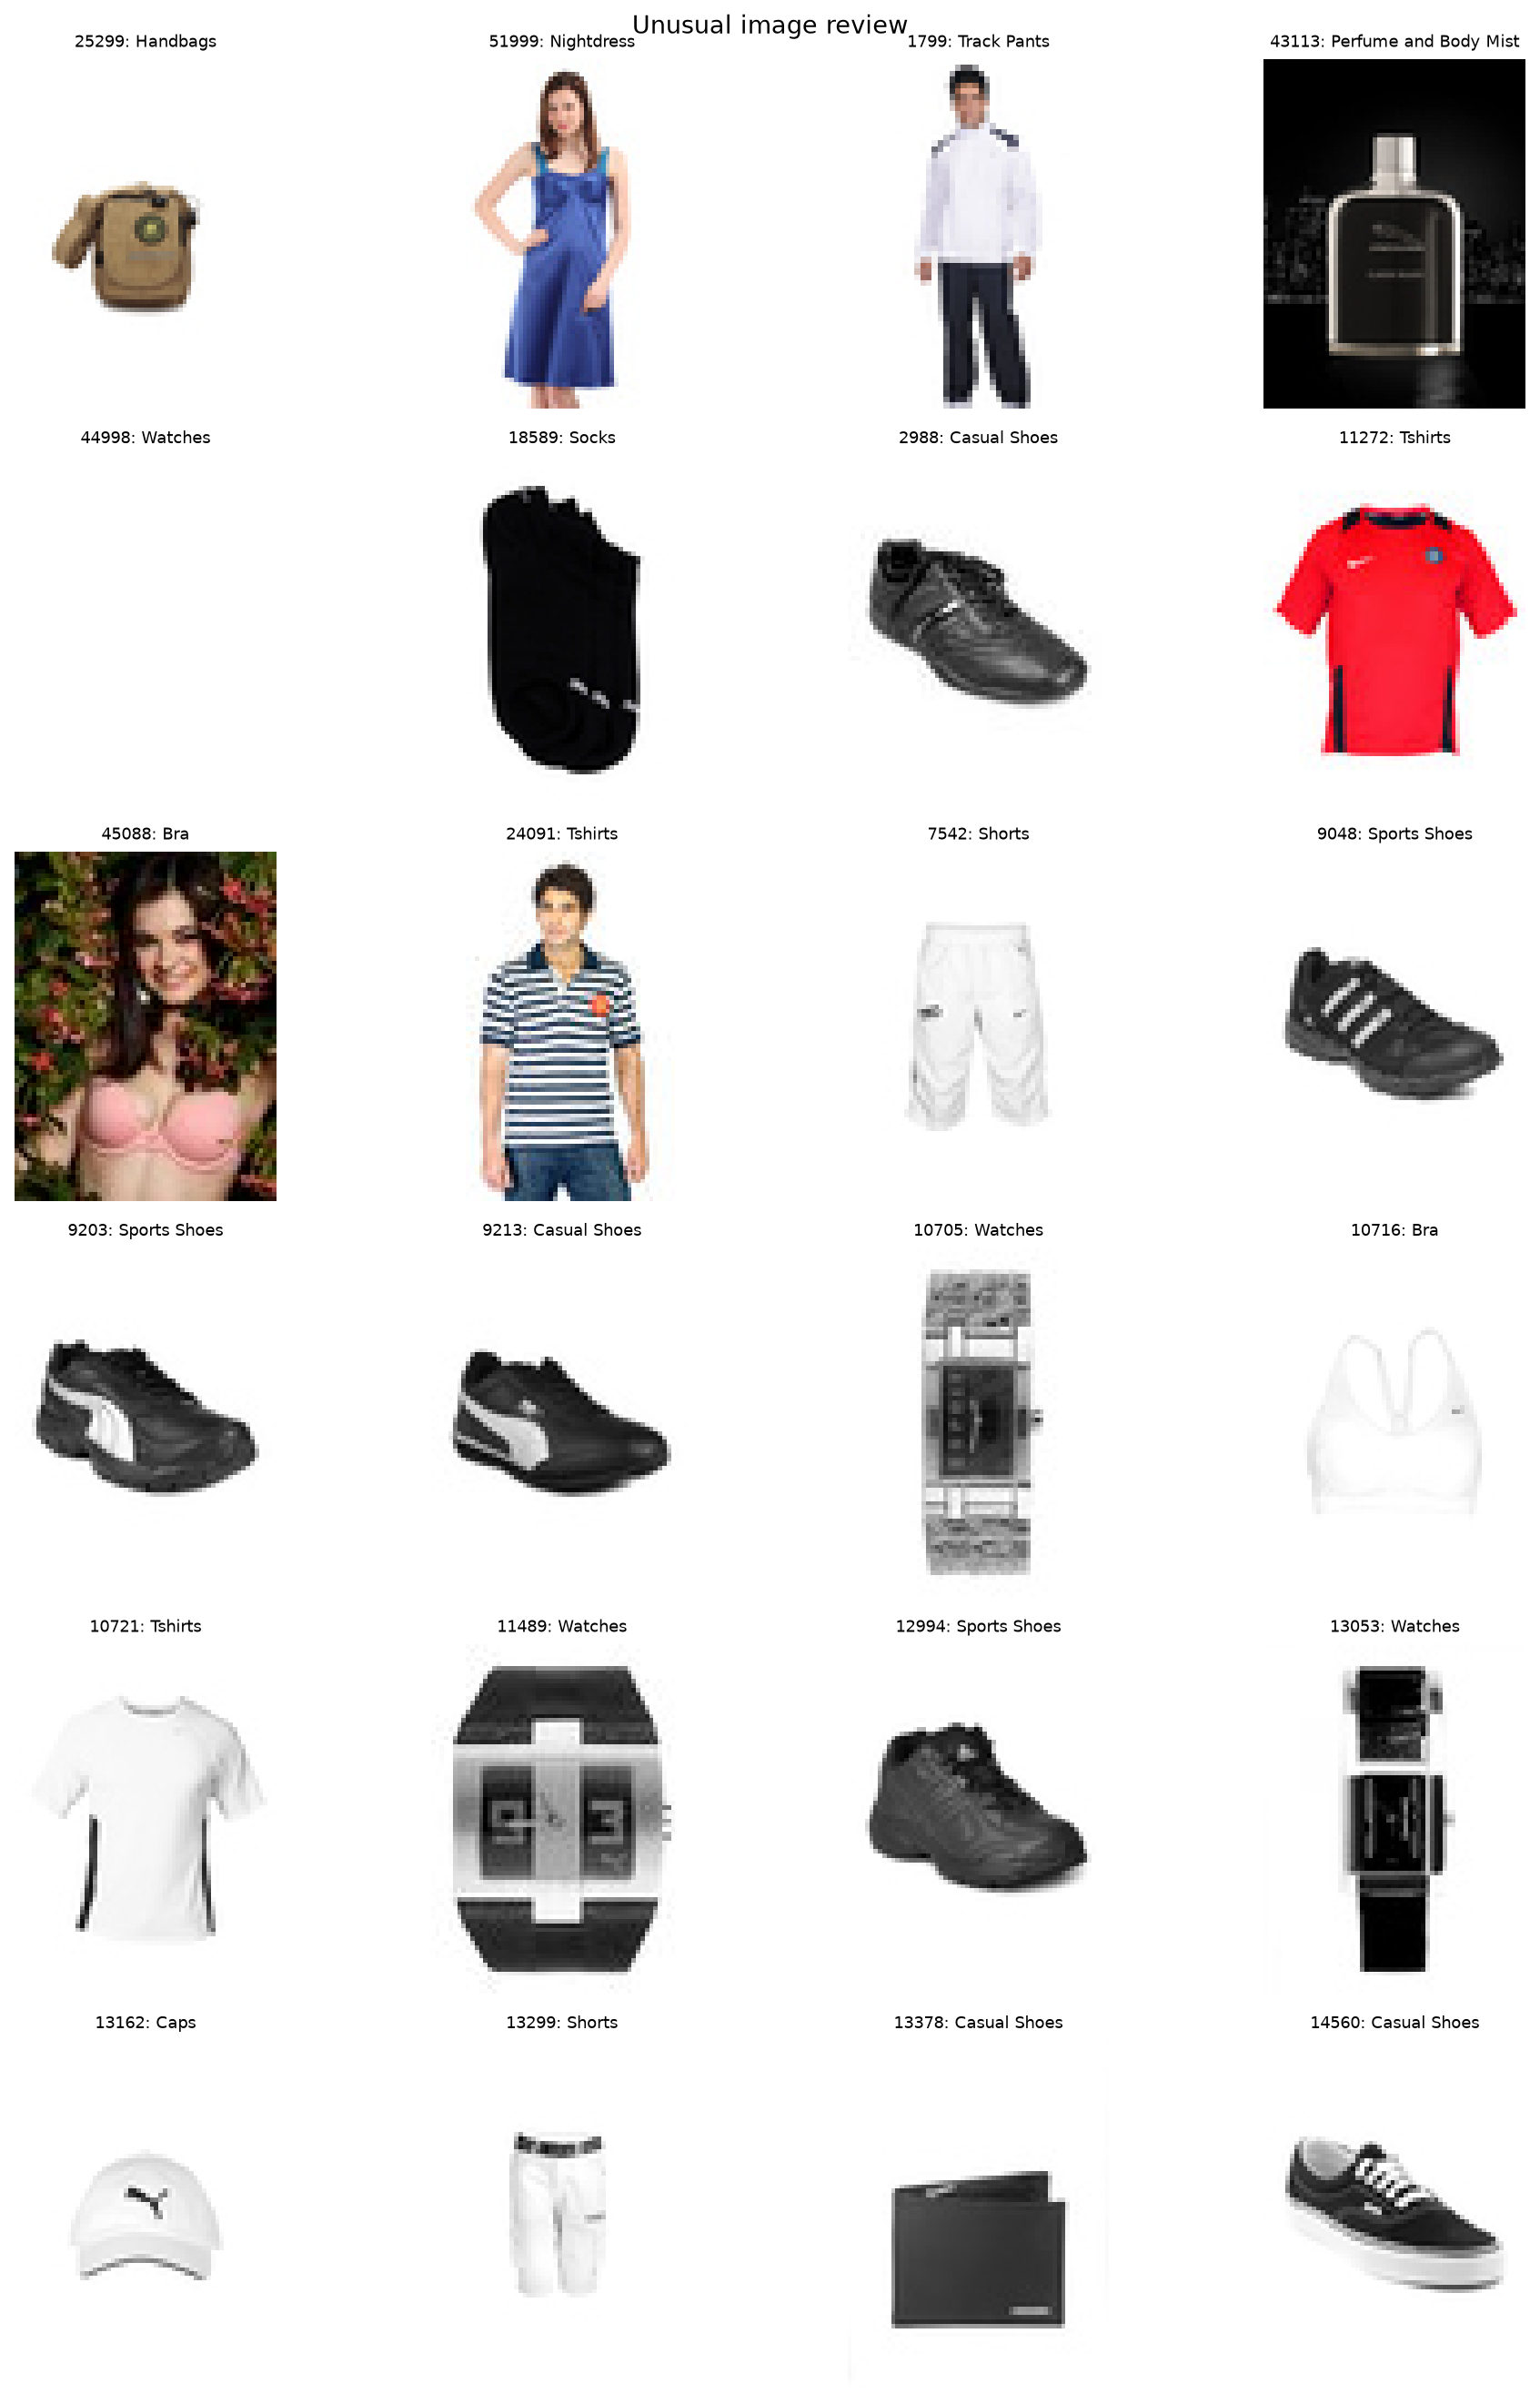

### Grayscale images

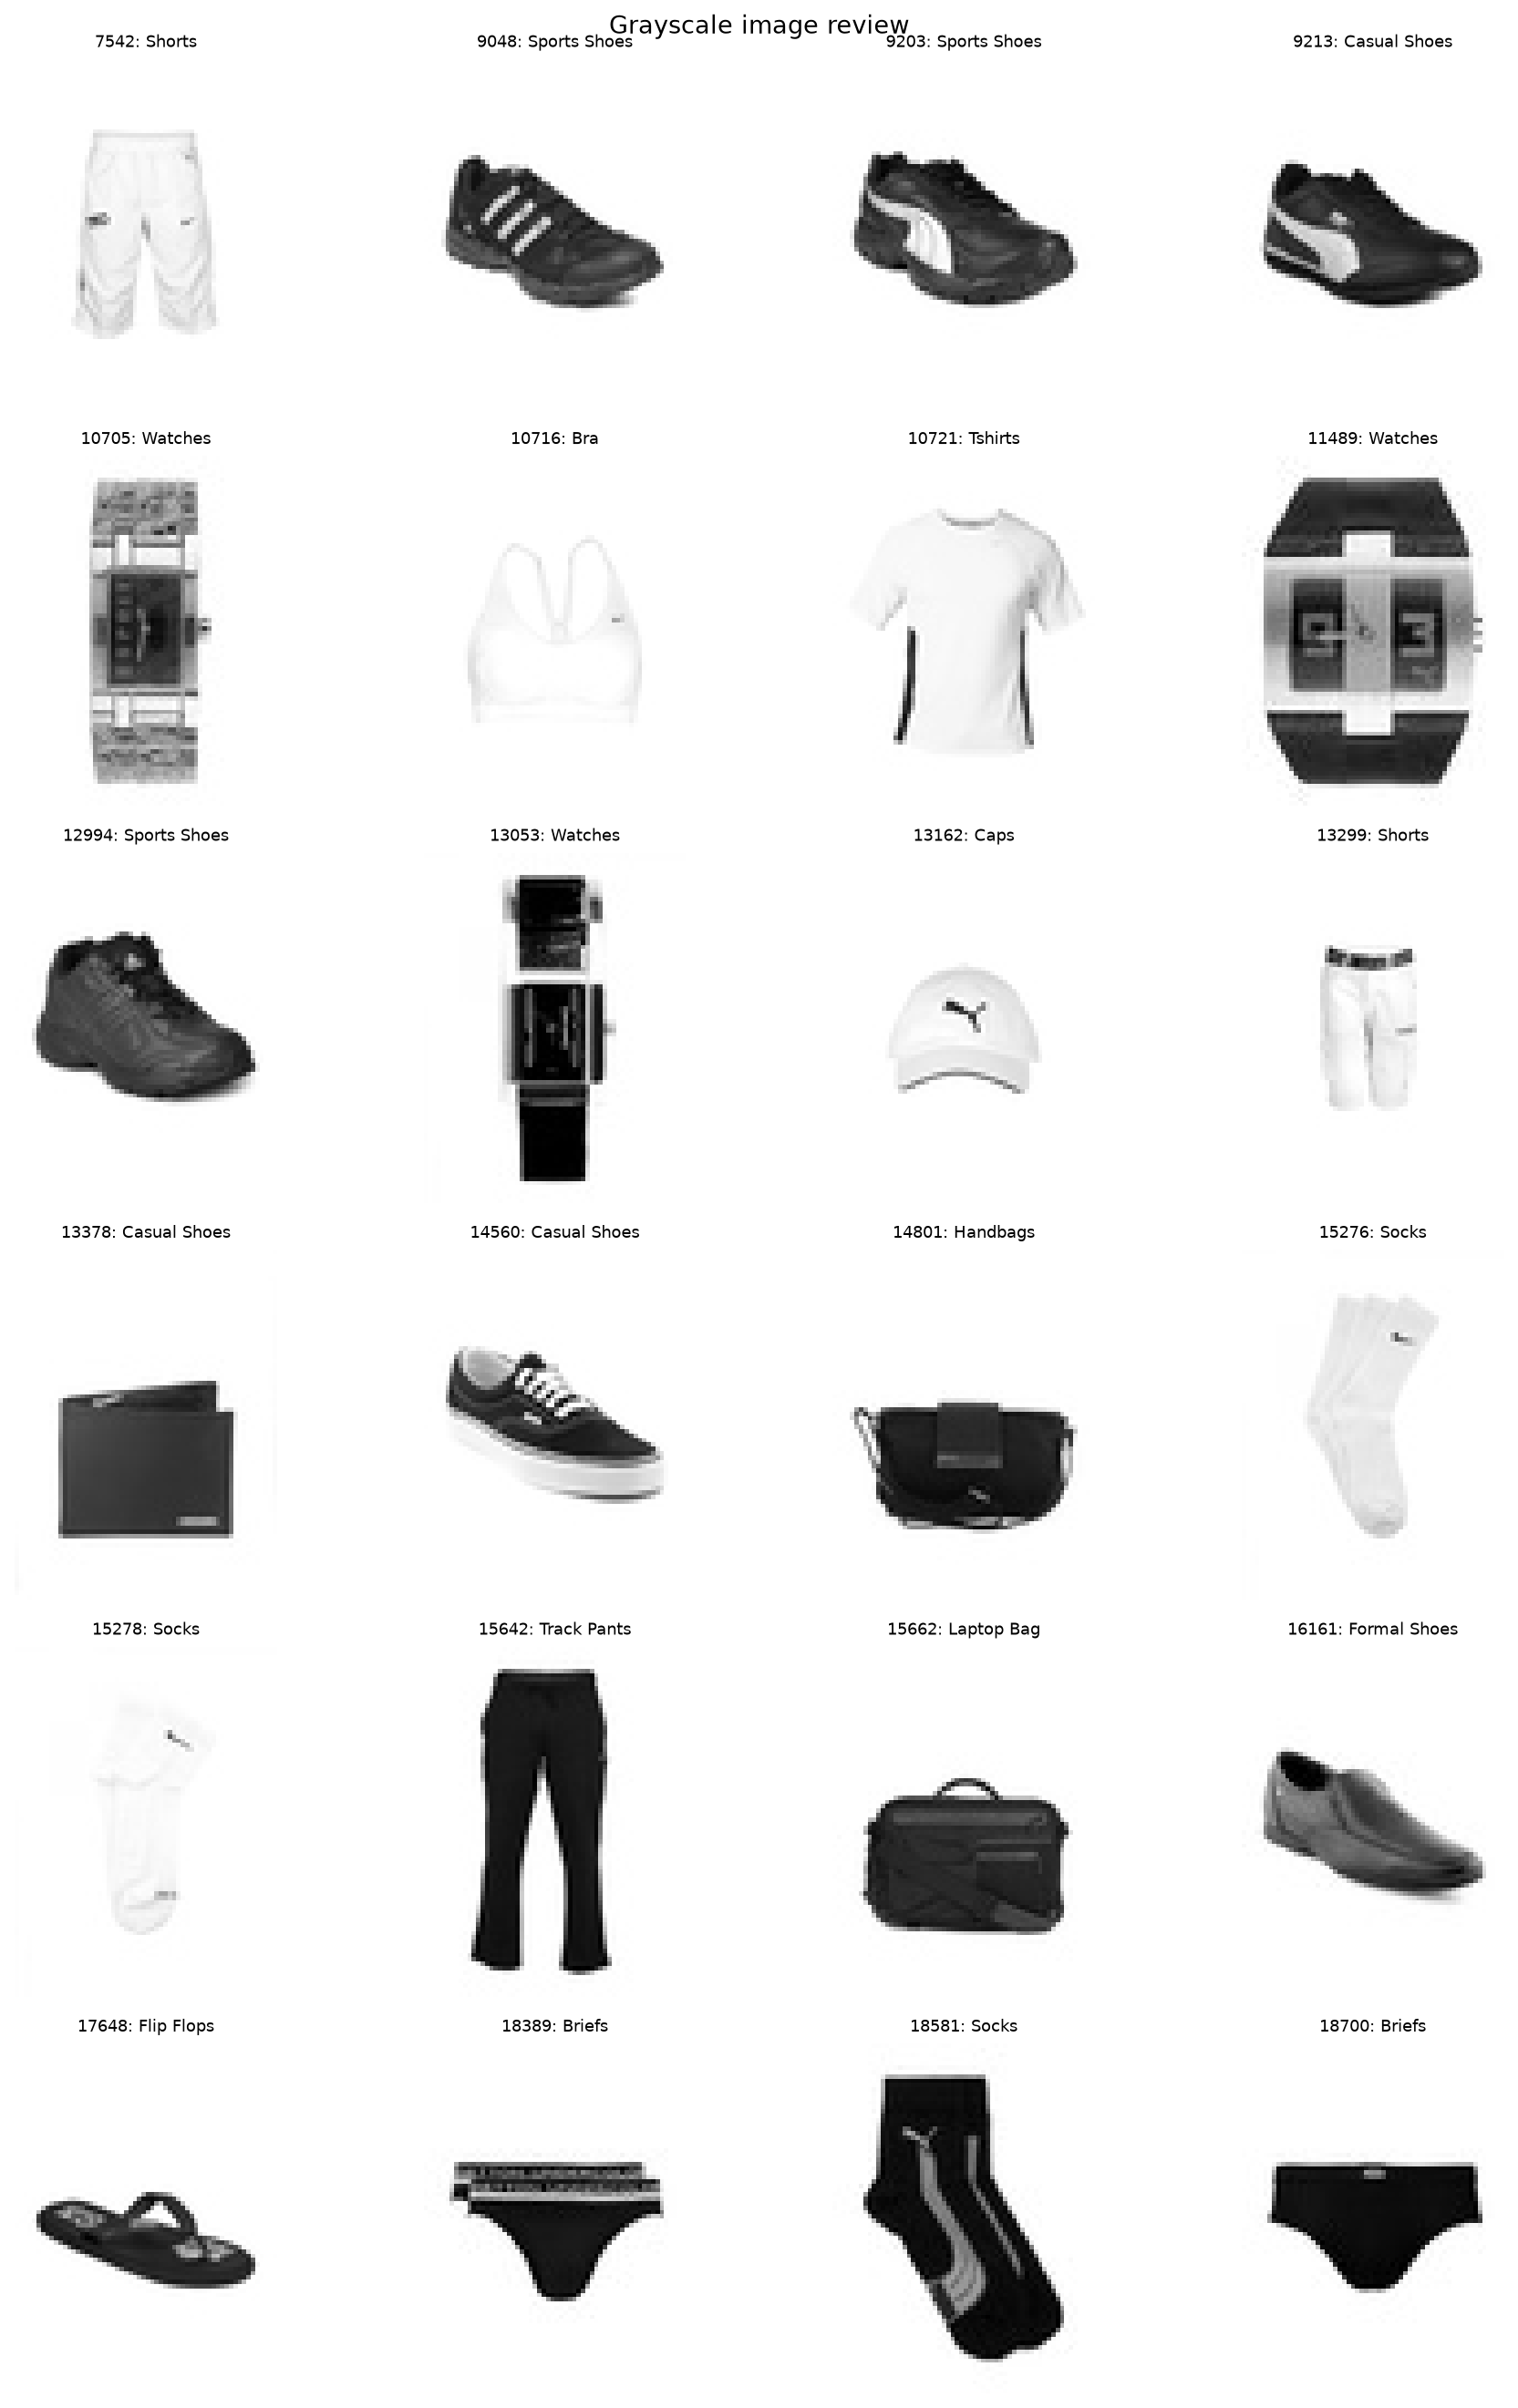

### Exact duplicates

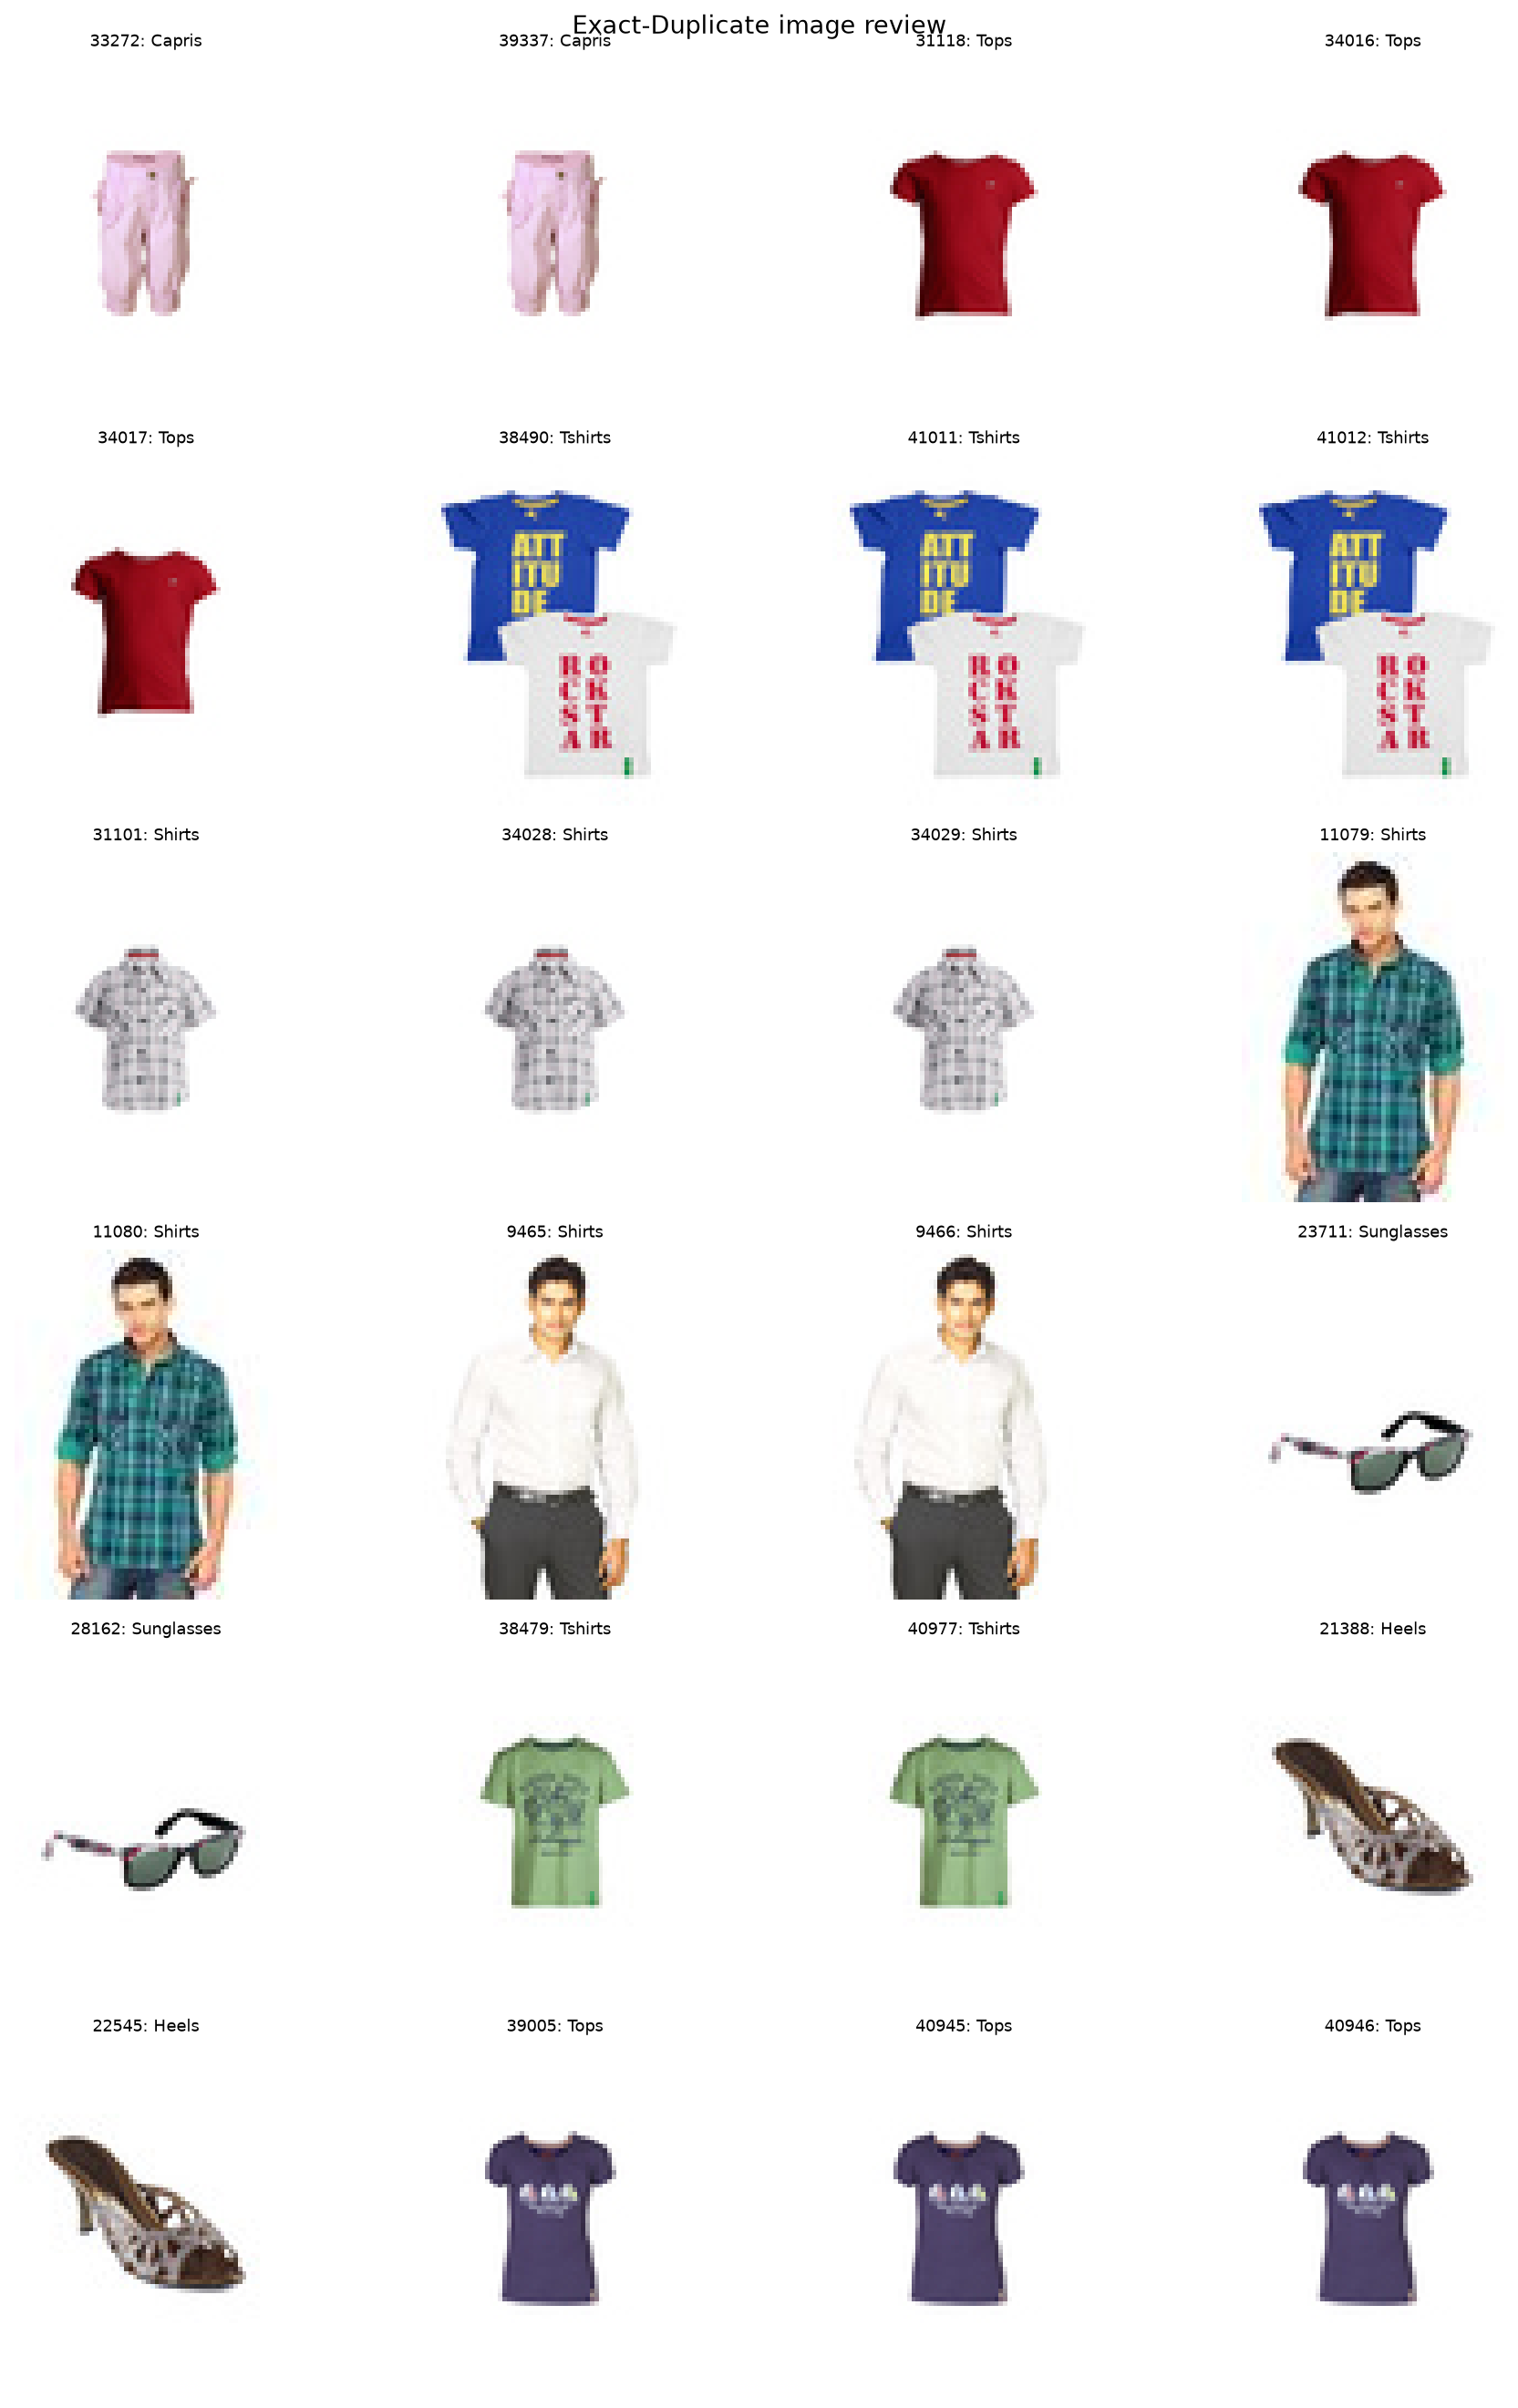

### Near-duplicate candidates

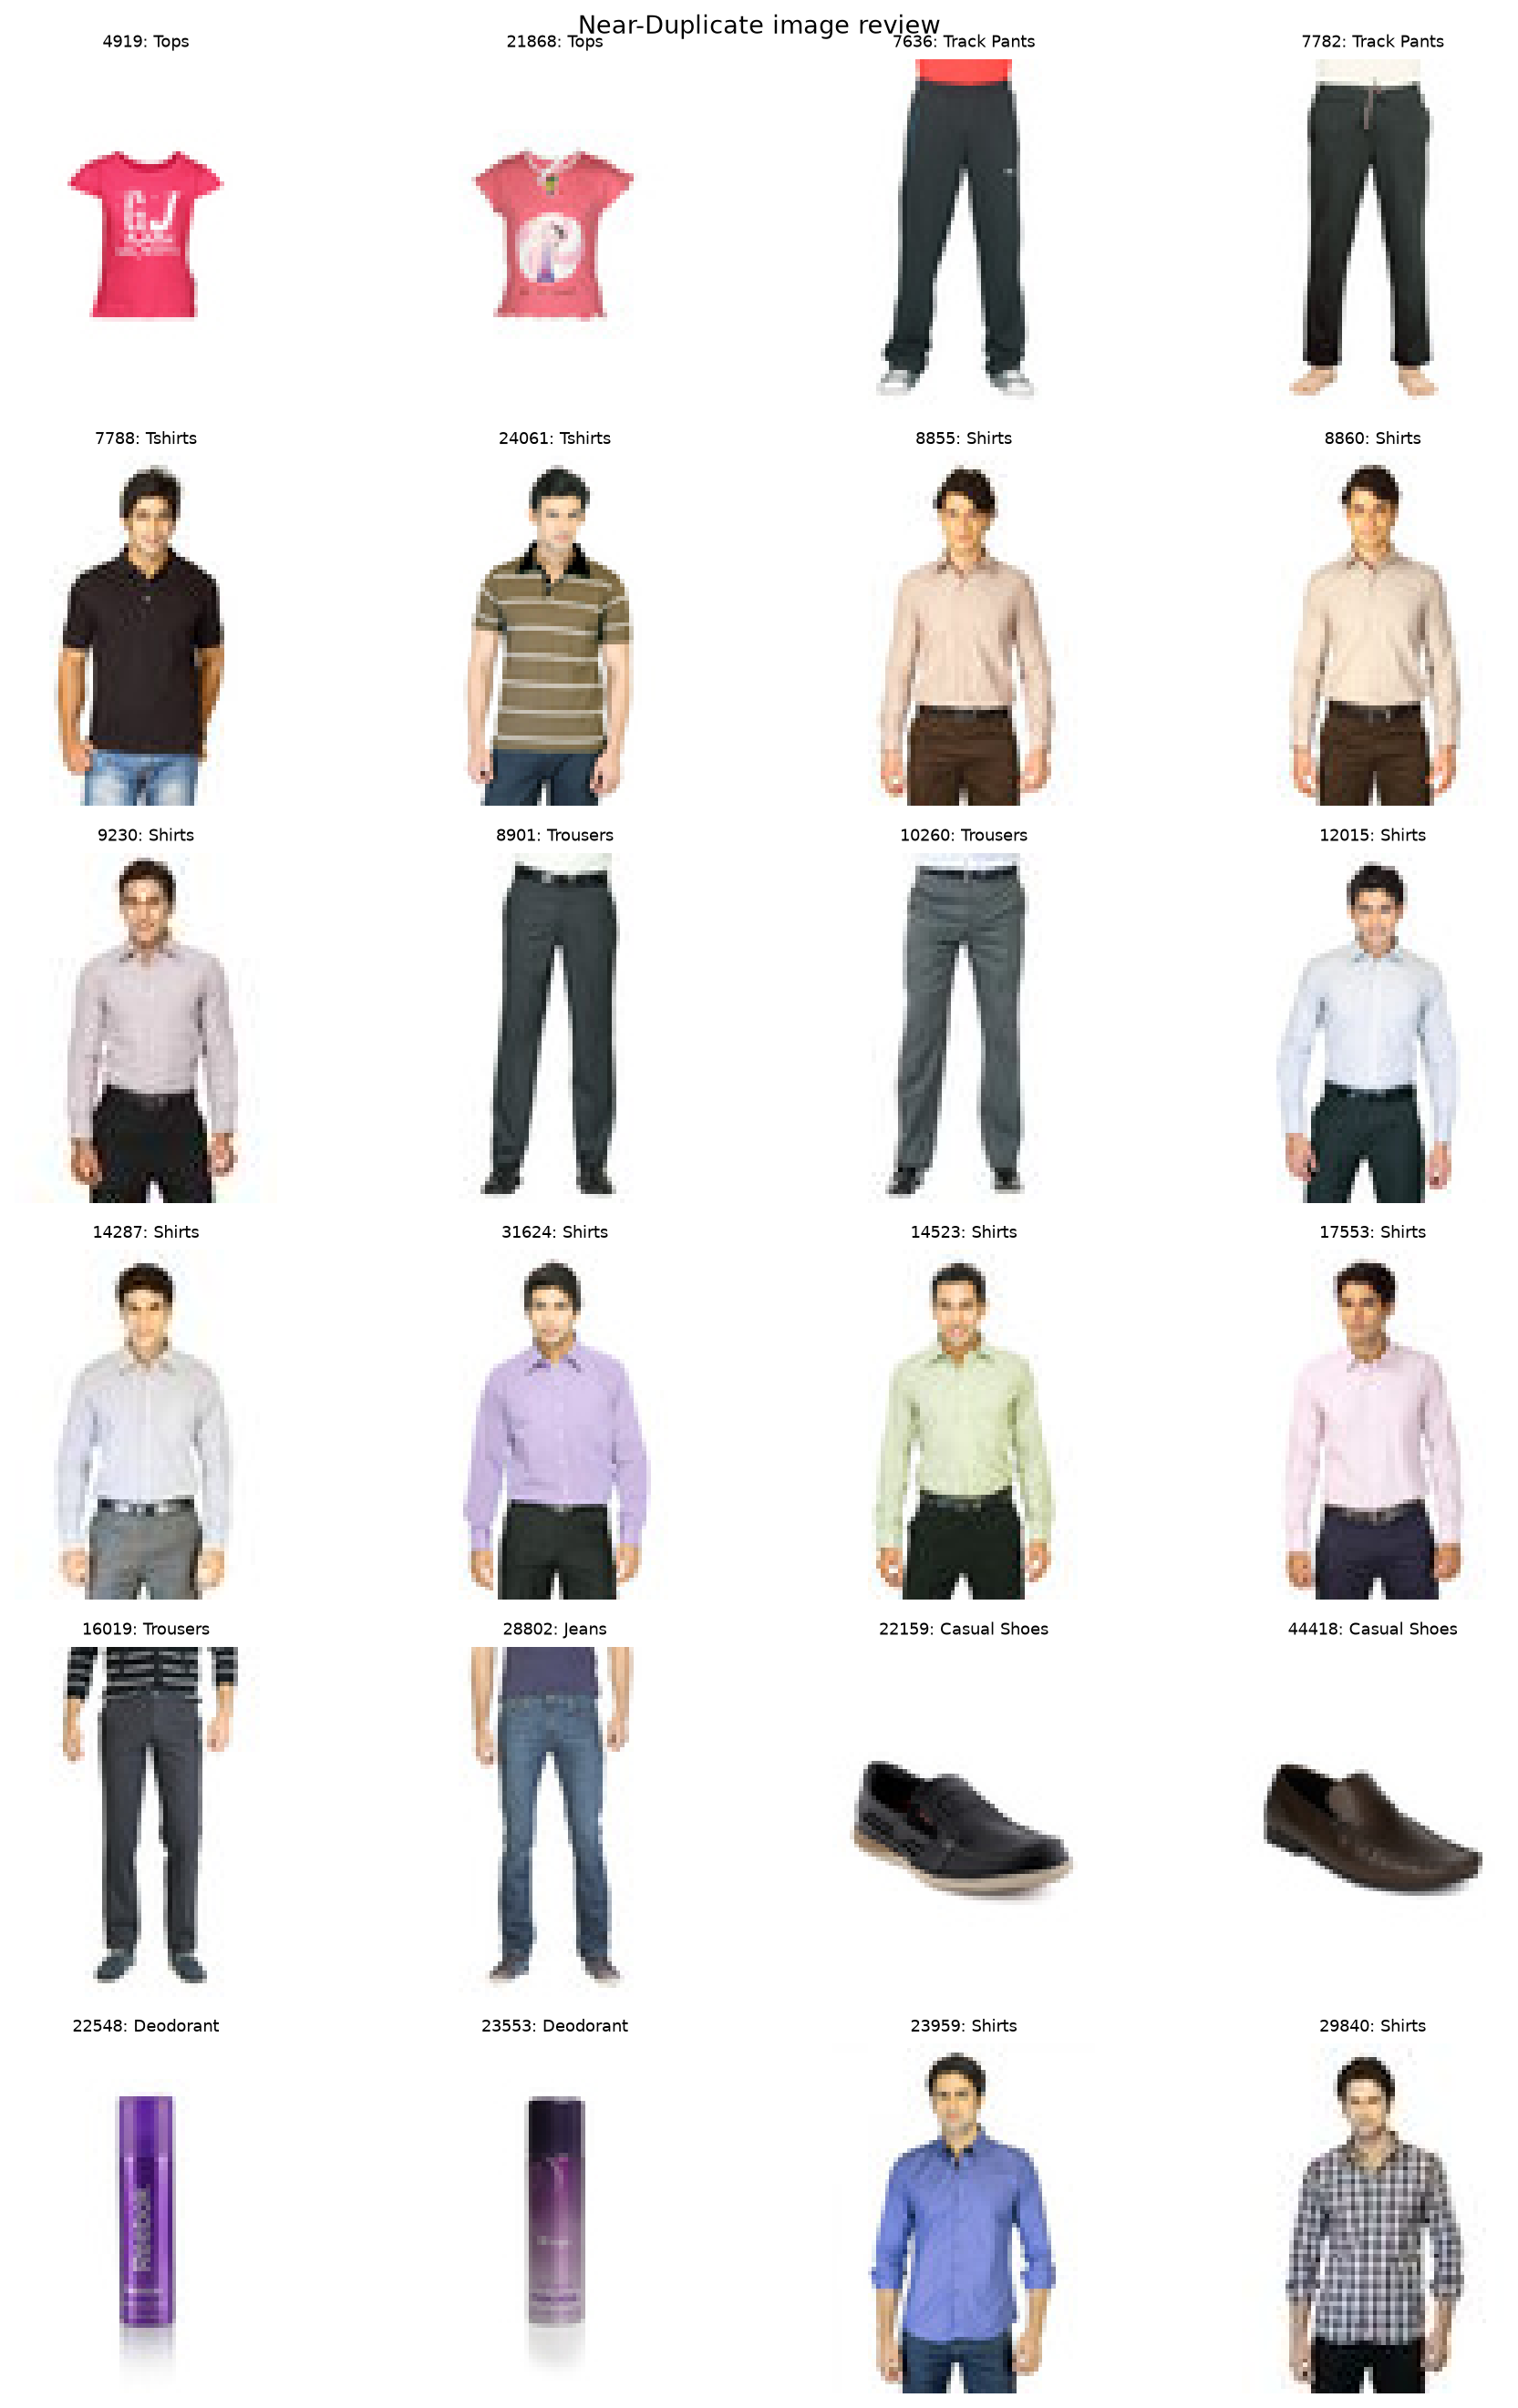

In [10]:
display(Markdown("### Blank image versus valid background extremes"))
display(DisplayImage(filename=str(OUTPUT / "brightness-background-review.png")))
display(Markdown(
    "**Decision:** exclude only the blank ID `44998` through `label_review.csv`. "
    "Keep valid bright and dark-background images. Use training-only brightness, "
    "contrast, and colour changes so the model learns the product instead of the background."
))

display(DisplayImage(filename=str(OUTPUT / "image-profiles.png")))
display(DisplayImage(filename=str(OUTPUT / "duplicate-summary.png")))

for name, title in (
    ("review-common.png", "Common classes"),
    ("review-rare.png", "Rare classes"),
    ("review-unusual.png", "Unusual image properties"),
    ("review-grayscale.png", "Grayscale images"),
    ("review-exact-duplicate.png", "Exact duplicates"),
    ("review-near-duplicate.png", "Near-duplicate candidates"),
):
    display(Markdown(f"### {title}"))
    display(DisplayImage(filename=str(OUTPUT / name)))

## 7. Combined report evidence

This is the single figure intended for the report. Detailed plots above remain notebook evidence.

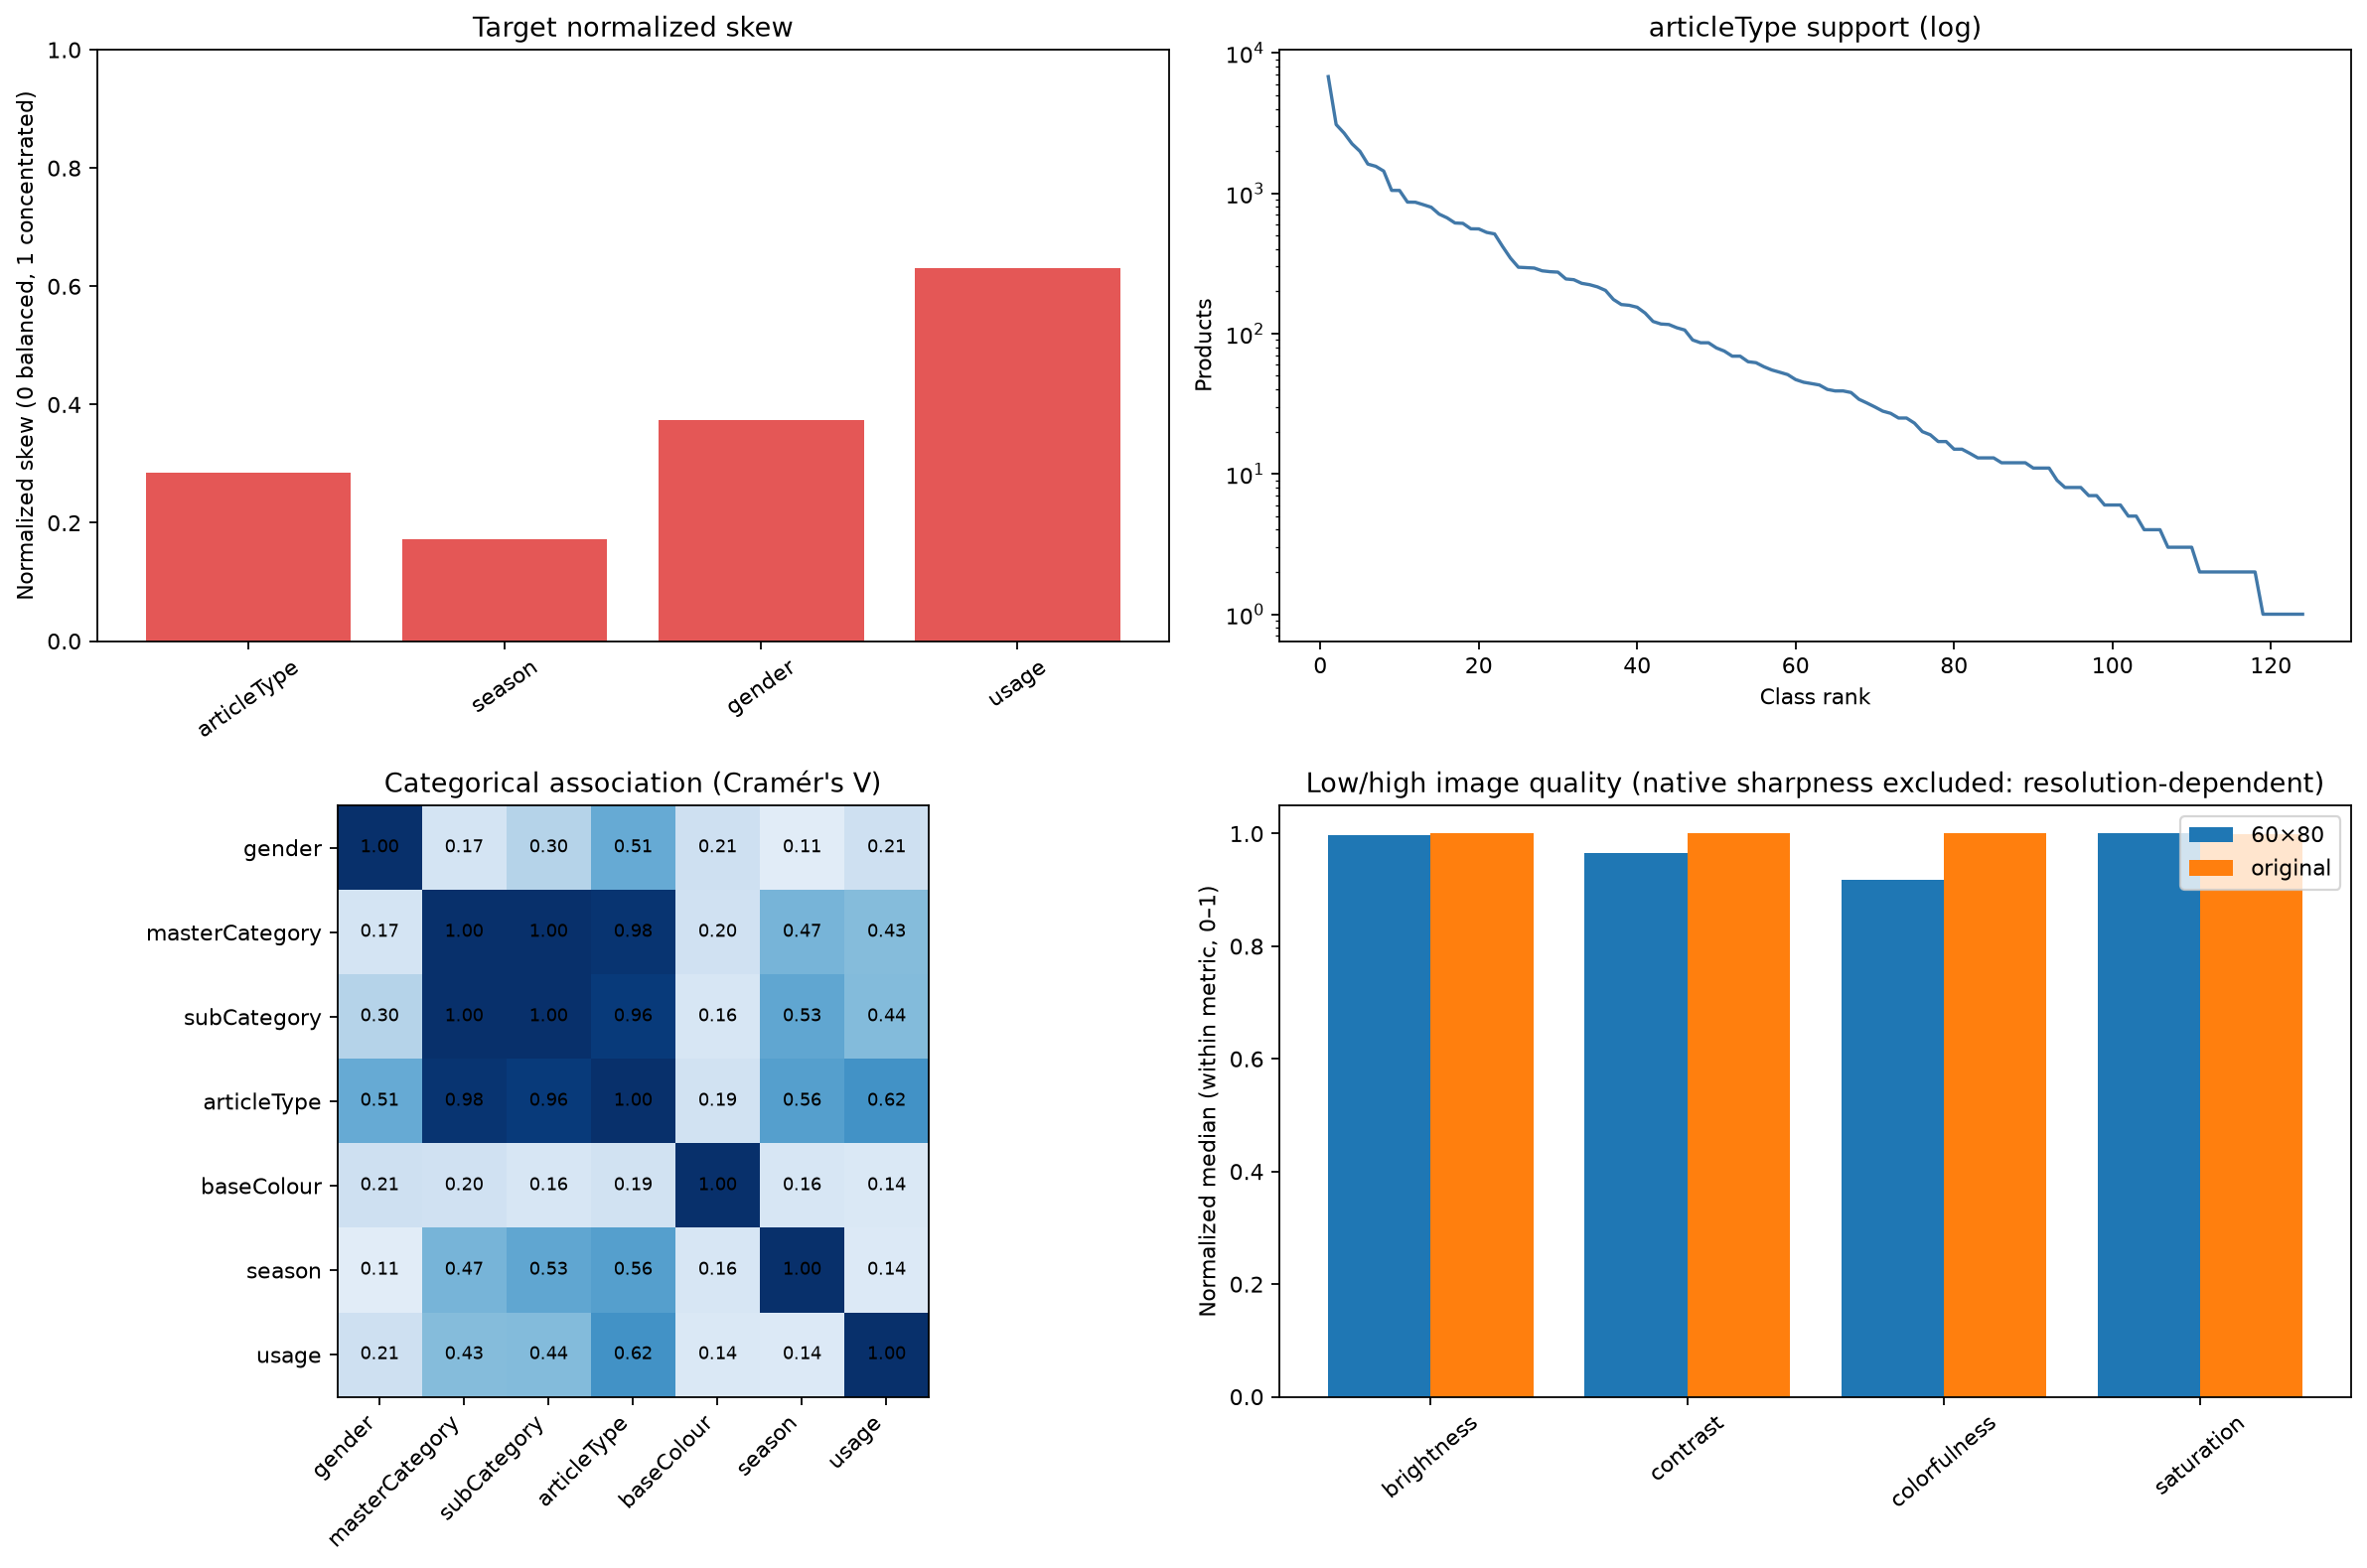

In [11]:
display(DisplayImage(filename=str(OUTPUT / "eda-report-summary.png")))

## 8. Findings and phase handoff

The next cell builds the summary from generated evidence. It separates facts, accepted image handling, and work assigned to later phases. The accepted data policies are recorded in `docs/decisions/0004`–`0006`.

In [12]:
article_rows = metadata_distributions.loc[metadata_distributions["column"].eq("articleType")]
rare_classes = int(support.loc[support["band"].isin(["1", "2", "3–4", "5–9"]), "class_count"].sum())
usage_skew = target_skew.set_index("column").loc["usage"]
season_blank = int(target_skew.set_index("column").loc["season", "blank_count"])
usage_blank = int(target_skew.set_index("column").loc["usage", "blank_count"])
usage_na = int(target_skew.set_index("column").loc["usage", "literal_na_count"])

text = f"""
### Factual findings

- The selected population contains **{population['usable_products']:,}** usable products from **{population['source_train_ids']:,}** official training IDs.
- `articleType` has **{len(article_rows):,}** observed labels; **{rare_classes:,}** have fewer than 10 usable products.
- The largest `usage` class contains **{usage_skew['majority_share']:.1%}** of nonblank products.
- Missing labels remain visible: `season` has **{season_blank:,}** blanks; `usage` has **{usage_blank:,}** blank and **{usage_na:,}** literal `"NA"` labels.
- Image evidence contains **{duplicate_counts['exact_group_count']:,}** exact groups covering **{duplicate_counts['exact_product_count']:,}** products.
- The sampled search found **{duplicate_counts['near_candidate_pair_count']:,}** near-duplicate candidate pairs among **{duplicate_counts['near_sample_product_count']:,}** products. These are not confirmed duplicates.
- Manual review found one blank product image, ID **{brightness_review['exclude_unusable_ids'][0]}**. IDs **{brightness_review['keep_valid_bright_ids'][0]}** and **{brightness_review['keep_valid_dark_background_ids'][0]}** are valid bright- and dark-background examples.

### Likely model effects

- Severe class imbalance makes plain accuracy misleading. Macro-F1 and per-class results will be needed.
- Tiny `articleType` classes may be impossible to learn or evaluate fairly.
- Strong target relationships may support a shared-backbone experiment, but this EDA cannot prove that it will improve generalisation.
- Bright and dark backgrounds can become shortcuts, meaning the model may learn the background instead of the product.
- Image-mode, quality, and duplicate differences can affect preprocessing and split safety.

### Accepted image handling

- Exclude only the confirmed blank ID **{brightness_review['exclude_unusable_ids'][0]}** through `label_review.csv`; keep the raw file unchanged.
- Keep valid bright and dark-background products. Use training-only brightness, contrast, and colour changes to improve robustness.

### Phase handoff

- Phase 1 applies the accepted scope, target-mask, correction, and duplicate-group policies from `docs/decisions/0004`–`0006`.
- Later experiments test separate classifiers against a shared backbone; the EDA does not assume which will win.
- Visual search uses the accepted proxy and human-rated evaluation rules in its own phase.
- This notebook remains evidence-only: it does not edit raw data or assign partitions.
"""
display(Markdown(text))


### Factual findings

- The selected population contains **38,612** usable products from **38,617** official training IDs.
- `articleType` has **124** observed labels; **32** have fewer than 10 usable products.
- The largest `usage` class contains **76.8%** of nonblank products.
- Missing labels remain visible: `season` has **20** blanks; `usage` has **1** blank and **71** literal `"NA"` labels.
- Image evidence contains **636** exact groups covering **1,399** products.
- The sampled search found **4,383** near-duplicate candidate pairs among **2,048** products. These are not confirmed duplicates.
- Manual review found one blank product image, ID **44998**. IDs **48716** and **43113** are valid bright- and dark-background examples.

### Likely model effects

- Severe class imbalance makes plain accuracy misleading. Macro-F1 and per-class results will be needed.
- Tiny `articleType` classes may be impossible to learn or evaluate fairly.
- Strong target relationships may support a shared-backbone experiment, but this EDA cannot prove that it will improve generalisation.
- Bright and dark backgrounds can become shortcuts, meaning the model may learn the background instead of the product.
- Image-mode, quality, and duplicate differences can affect preprocessing and split safety.

### Accepted image handling

- Exclude only the confirmed blank ID **44998** through `label_review.csv`; keep the raw file unchanged.
- Keep valid bright and dark-background products. Use training-only brightness, contrast, and colour changes to improve robustness.

### Phase handoff

- Phase 1 applies the accepted scope, target-mask, correction, and duplicate-group policies from `docs/decisions/0004`–`0006`.
- Later experiments test separate classifiers against a shared backbone; the EDA does not assume which will win.
- Visual search uses the accepted proxy and human-rated evaluation rules in its own phase.
- This notebook remains evidence-only: it does not edit raw data or assign partitions.
